In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import shap
import json
import networkx as nx
import seaborn as sns
import lingam
import warnings

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from typing import Dict
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import ccf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.api import VAR
from scipy import stats
from dotenv import load_dotenv


from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report
)



load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")

warnings.filterwarnings('ignore')
print("✅ Imports loaded successfully!")

✅ Imports loaded successfully!


<br> <br> <br>

### Read the the .csv file

In [15]:
lag_features_path = "../../data/azure_pm/lag_features/machine_98_lag_features.csv"
df_machine_98 = pd.read_csv(lag_features_path)
print(f"Loaded shape: {df_machine_98.shape}")
df_machine_98.head()

Loaded shape: (8757, 65)


,datetime,volt,rotate,pressure,vibration,errorID,comp,failure,target,volt_lag_1h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
0,2015-01-01 06:00:00,0.303137,0.604476,0.271993,0.621000,0,0,0,0,0.000000,...,0.0,0.0,0.0,0.0,6,3,0,0,0,0
1,2015-01-01 07:00:00,0.455312,0.635538,0.480756,0.645421,0,0,0,0,0.303137,...,0.0,0.0,0.0,0.0,7,3,0,0,1,1
2,2015-01-01 08:00:00,0.449470,0.540973,0.427196,0.356126,0,0,0,0,0.455312,...,0.0,0.0,0.0,0.0,8,3,0,1,2,2
3,2015-01-01 09:00:00,0.408248,0.687752,0.378658,0.254123,0,0,0,0,0.449470,...,0.0,0.0,0.0,0.0,9,3,0,1,3,3
4,2015-01-01 10:00:00,0.486041,0.518746,0.454206,0.351050,0,0,0,0,0.408248,...,0.0,0.0,0.0,0.0,10,3,0,1,4,4


<br> <br>

### Read Causal graph file

In [16]:
with open("../../causality_graph/azure_pm/machine_98/structured_adjacency.json", "r") as f:
    structured_adjacency = json.load(f)

print(f"Loaded {len(structured_adjacency)} edges from structured_adjacency.json")

Loaded 774 edges from structured_adjacency.json


In [17]:
structured_adjacency[0:2]

[{'source_feature': 'volt',
  'target_feature': 'volt_lag_1h',
  'effect_strength': 0.01031322375254026},
 {'source_feature': 'volt',
  'target_feature': 'volt_lag_24h',
  'effect_strength': 0.13918872976475608}]

In [18]:
df_machine_98.drop(columns=["datetime", "failure", "errorID"])

,volt,rotate,pressure,vibration,comp,target,volt_lag_1h,volt_lag_6h,volt_lag_12h,volt_lag_24h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
0,0.303137,0.604476,0.271993,0.621000,0,0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,6,3,0,0,0,0
1,0.455312,0.635538,0.480756,0.645421,0,0,0.303137,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,7,3,0,0,1,1
2,0.449470,0.540973,0.427196,0.356126,0,0,0.455312,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,8,3,0,1,2,2
3,0.408248,0.687752,0.378658,0.254123,0,0,0.449470,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,9,3,0,1,3,3
4,0.486041,0.518746,0.454206,0.351050,0,0,0.408248,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,10,3,0,1,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8752,0.578128,0.640681,0.390571,0.357513,0,0,0.267632,0.686530,0.544128,0.582918,...,0.0,0.0,0.0,0.0,2,3,0,0,116,76
8753,0.327834,0.639340,0.339816,0.484520,0,0,0.578128,0.194512,0.554888,0.446084,...,0.0,0.0,0.0,0.0,3,3,0,0,117,77
8754,0.578074,0.607038,0.513075,0.416149,0,0,0.327834,0.381298,0.408099,0.516699,...,0.0,0.0,0.0,0.0,4,3,0,0,118,78
8755,0.526413,0.539851,0.582220,0.495210,0,0,0.578074,0.428880,0.601410,0.485337,...,0.0,0.0,0.0,0.0,5,3,0,0,119,79


<br> <br>

### Read ML models

In [19]:
model_dir = "../../model/azure_pm/machine_98"
pkl_files = glob.glob(os.path.join(model_dir, "*.pkl"))

models = {}
for file_path in pkl_files:
    model_name = os.path.splitext(os.path.basename(file_path))[0]
    with open(file_path, "rb") as f:
        models[model_name] = pickle.load(f)

print(f"Loaded {len(models)} models: {list(models.keys())}")

Loaded 4 models: ['CatBoost', 'LightGBM', 'RandomForest', 'XGBoost']


<br> <br>

#### Generate a random row

In [20]:
def get_random_nonzero_target_row(df):
    filtered = df[df["target"] != 0]
    if filtered.empty:
        return None
    return filtered.sample(n=1, random_state=np.random.randint(0, 10000)).iloc[0]


<br> <br>

#### Get top n rows using SHAP

In [21]:
def get_top_n_shap_features(random_row, model_dict, top_n=10):
    model = model_dict['model']
    feature_names = model_dict['feature_names']

    # Prepare the row as a DataFrame for SHAP and ensure numeric types
    X_row = random_row.to_frame().T[feature_names]
    X_row = X_row.apply(pd.to_numeric, errors='coerce')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_row)

    if isinstance(shap_values, list):
        shap_abs = np.sum([np.abs(sv).reshape(-1) for sv in shap_values], axis=0)
    else:
        shap_abs = np.abs(shap_values).reshape(-1)

    min_len = min(len(feature_names), len(shap_abs))
    df_shap = pd.DataFrame({
        'feature_name': feature_names[:min_len],
        'feature_importance': shap_abs[:min_len]
    }).sort_values('feature_importance', ascending=False).head(top_n).reset_index(drop=True)

    return df_shap

<br> <br> <br>

#### Run the random row generation method

In [22]:
# Example usage:
random_row = get_random_nonzero_target_row(df_machine_98)
random_row.drop(["datetime", "failure", "target"], inplace=True)
# random_row.apply(pd.to_numeric)
display(random_row.to_frame().T)

,volt,rotate,pressure,vibration,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,volt_lag_24h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
679,0.416132,0.622689,0.792252,0.433176,0,0,0.439397,0.480602,0.341975,0.577855,...,0.0,4.0,0.0,0.0,13,3,0,1,679,7


<br> <br> 

#### Run the SHAP query

In [23]:
my_models = {
    "catboost_model": 'CatBoost', 
    "lightgbm_model": 'LightGBM', 
    "randomforest_model": 'RandomForest', 
    "xgboost_model": 'XGBoost'
}

# model = models["XGBoost"]
model = models[my_models["catboost_model"]]
# model = models[my_models["lightgbm_model"]]
# model = models[my_models["randomforest_model"]]
# model = models[my_models["xgboost_model"]]
# model



In [24]:
models[my_models["catboost_model"]]

{'model': <catboost.core.CatBoostClassifier at 0x1f75de49640>,
 'feature_names': ['volt',
  'rotate',
  'pressure',
  'vibration',
  'errorID',
  'comp',
  'volt_lag_1h',
  'volt_lag_6h',
  'volt_lag_12h',
  'volt_lag_24h',
  'volt_mean_24h',
  'volt_std_24h',
  'volt_min_24h',
  'volt_max_24h',
  'volt_mean_6h',
  'volt_std_6h',
  'rotate_lag_1h',
  'rotate_lag_6h',
  'rotate_lag_12h',
  'rotate_lag_24h',
  'rotate_mean_24h',
  'rotate_std_24h',
  'rotate_min_24h',
  'rotate_max_24h',
  'rotate_mean_6h',
  'rotate_std_6h',
  'pressure_lag_1h',
  'pressure_lag_6h',
  'pressure_lag_12h',
  'pressure_lag_24h',
  'pressure_mean_24h',
  'pressure_std_24h',
  'pressure_min_24h',
  'pressure_max_24h',
  'pressure_mean_6h',
  'pressure_std_6h',
  'vibration_lag_1h',
  'vibration_lag_6h',
  'vibration_lag_12h',
  'vibration_lag_24h',
  'vibration_mean_24h',
  'vibration_std_24h',
  'vibration_min_24h',
  'vibration_max_24h',
  'vibration_mean_6h',
  'vibration_std_6h',
  'errorID_lag_1h',
  'e

,feature_name,feature_importance
0,comp_lag_12h,0.336690
1,error_count_24h,0.252627
2,volt_max_24h,0.197883
3,hours_since_error,0.176486
4,hours_since_maint,0.107648


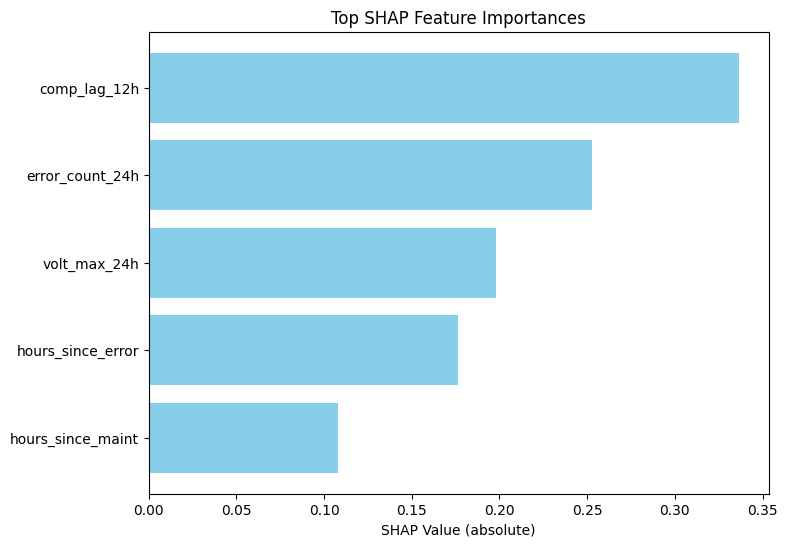

In [25]:
df_shap = get_top_n_shap_features(random_row=random_row, model_dict=model, top_n=5)
display(df_shap)


# Visualize SHAP values from df_shap as a horizontal bar plot
plt.figure(figsize=(8, 6))
plt.barh(df_shap['feature_name'][::-1], df_shap['feature_importance'][::-1], color='skyblue')
plt.xlabel('SHAP Value (absolute)')
plt.title('Top SHAP Feature Importances')
plt.show()

<br> <br> <br>

#### Map the top n SHAP to causal graph - Simple visualization

In [26]:
def visualize_and_json_shap_causal(df_shap, structured_adjacency):
    """
    Visualize the subgraph of the causal graph containing top SHAP features and return the subgraph as JSON.

    Args:
        df_shap (pd.DataFrame): DataFrame with a 'feature_name' column.
        structured_adjacency (list): List of dicts with 'source_feature' and 'target_feature' keys.

    Returns:
        str: JSON string of the subgraph.
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    import json

    top_features = set(df_shap["feature_name"])
    sub_edges = []
    for edge in structured_adjacency:
        if (edge["source_feature"] in top_features) or (edge["target_feature"] in top_features):
            sub_edges.append((edge["source_feature"], edge["target_feature"]))

    G = nx.DiGraph()
    G.add_edges_from(sub_edges)

    node_colors = ['orange' if node in top_features else 'skyblue' for node in G.nodes()]
    edge_colors = ['red' if (u in top_features and v in top_features) else 'gray' for u, v in G.edges()]

    # Use graphviz_layout if available for better readability, else fallback to spring_layout
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=0.8, iterations=200)

    plt.figure(figsize=(max(12, len(G.nodes()) * 0.7), max(8, len(G.nodes()) * 0.5)))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=1400,
        font_size=11,
        arrowsize=22,
        linewidths=2,
        font_weight='bold'
    )
    plt.title("Subgraph: Top SHAP Features in Causal Graph", fontsize=16)
    plt.tight_layout()
    plt.show()

    subgraph_json = {
        "nodes": [
            {"id": node, "highlight": node in top_features}
            for node in G.nodes()
        ],
        "edges": [
            {
                "source": u,
                "target": v,
                "highlight": (u in top_features and v in top_features)
            }
            for u, v in G.edges()
        ]
    }
    return json.dumps(subgraph_json, indent=2)



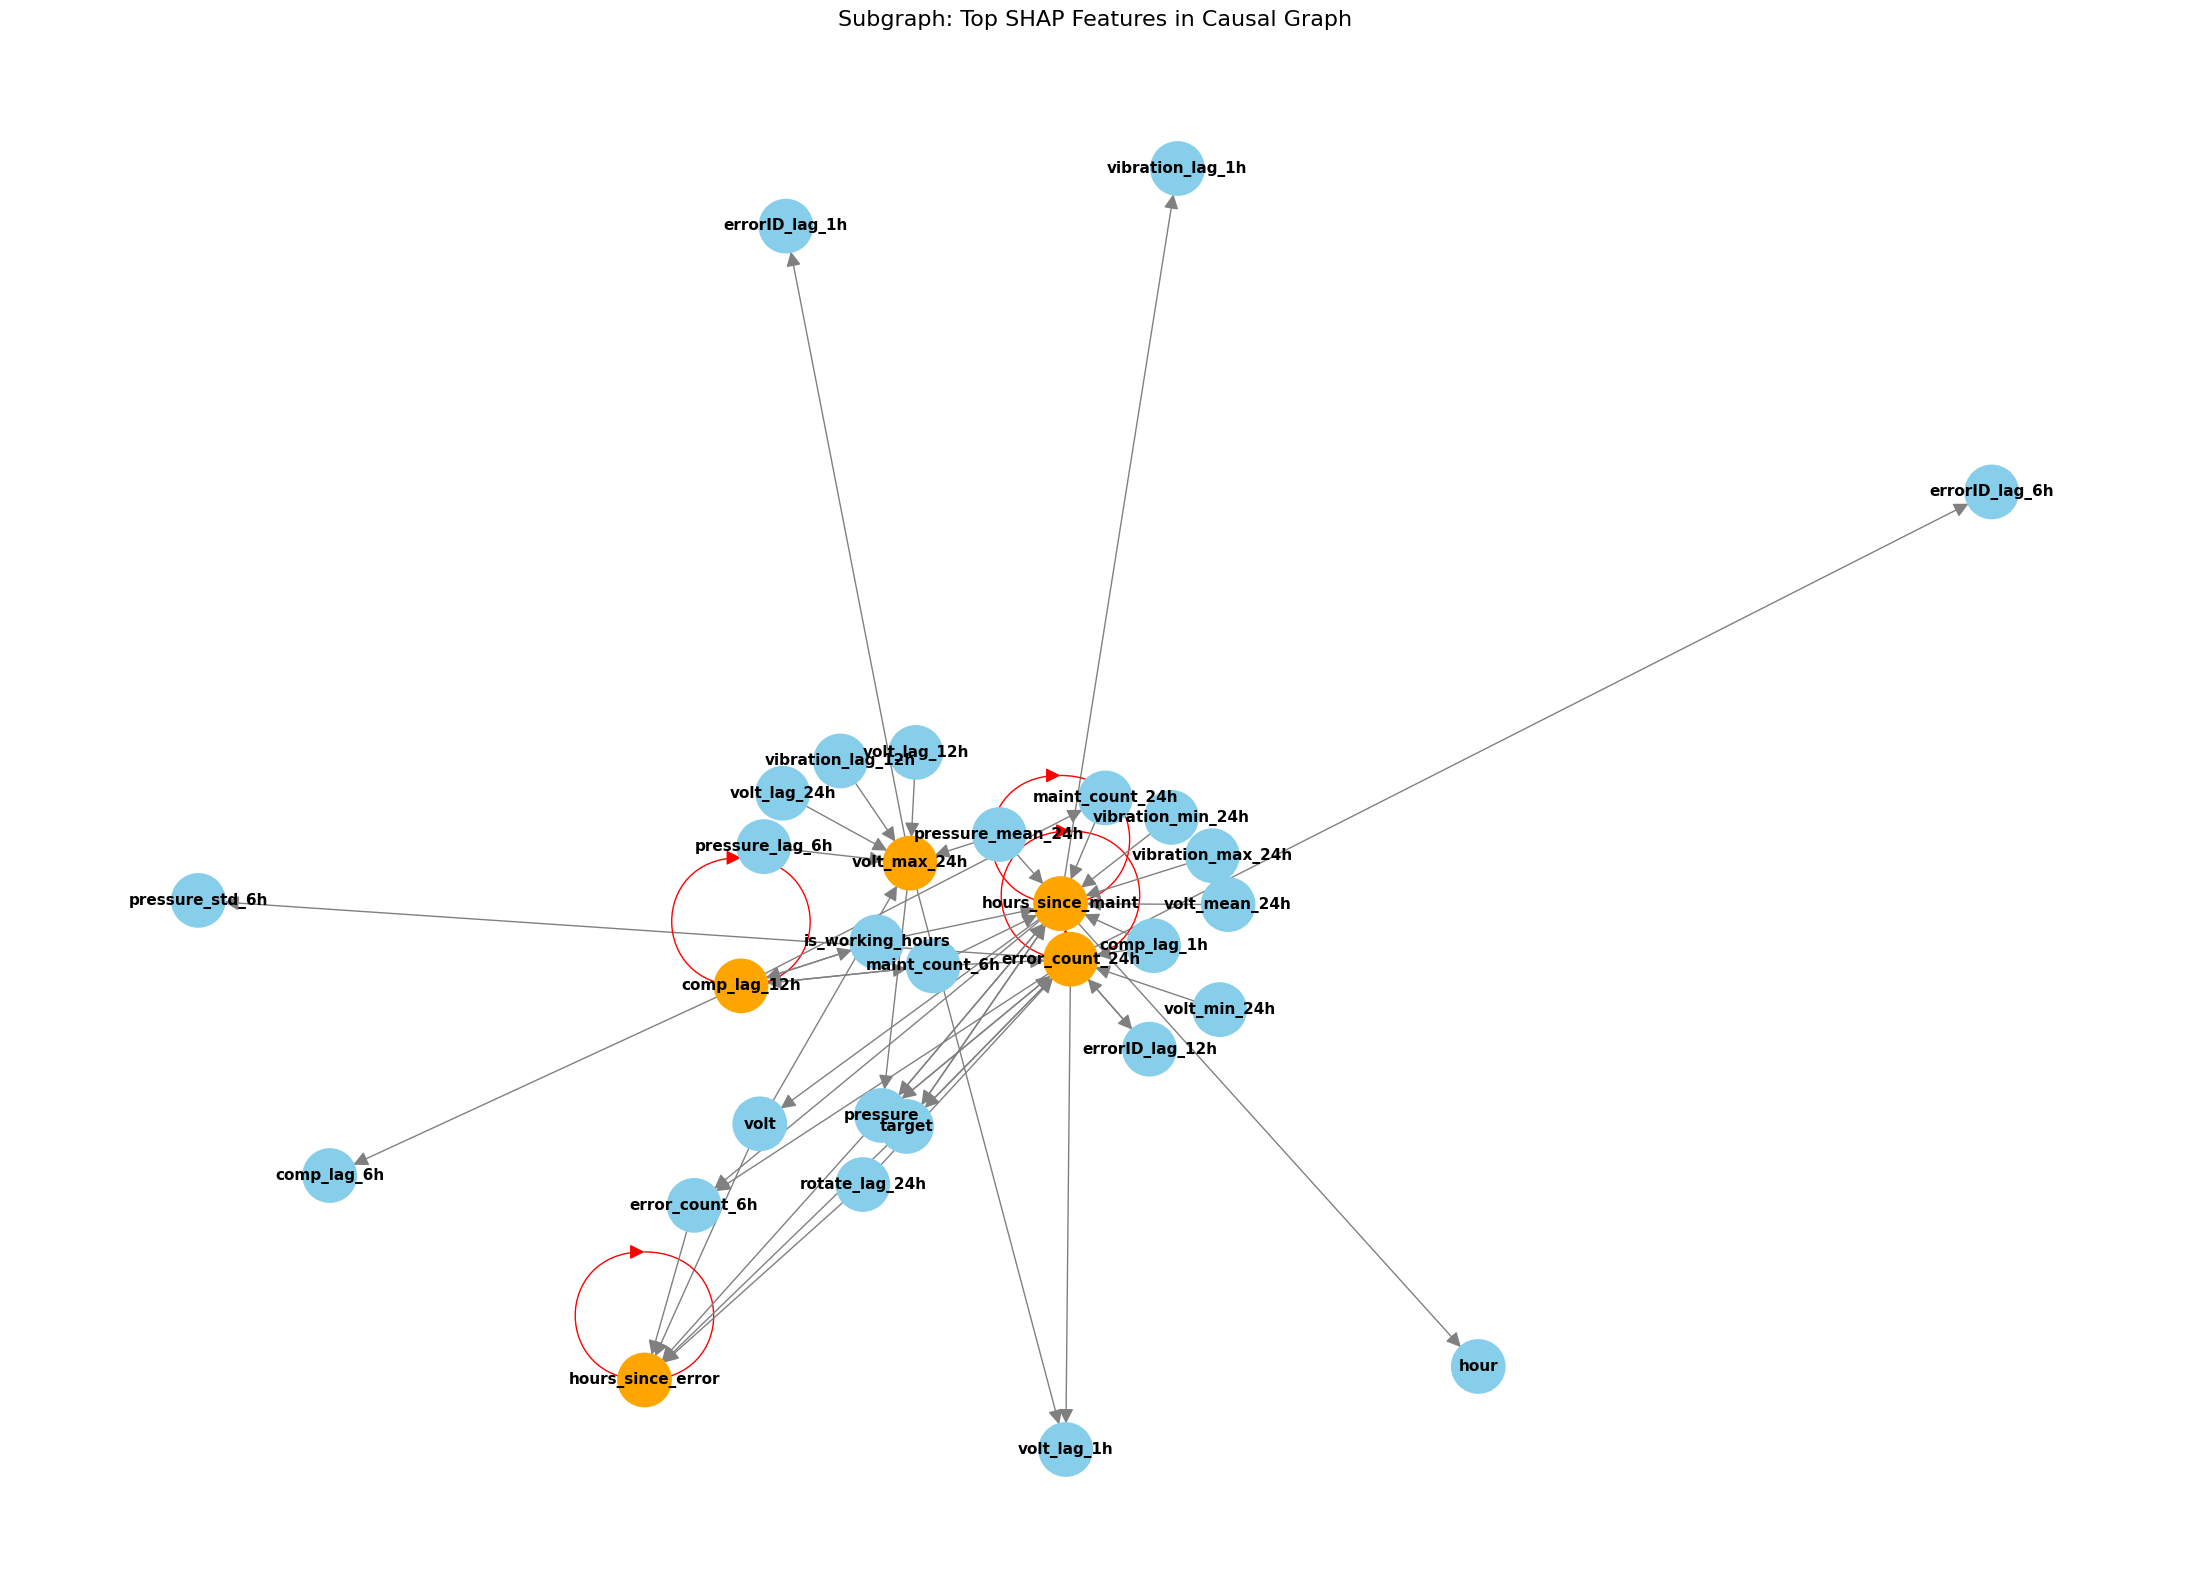

In [27]:
# Example usage:
result = visualize_and_json_shap_causal(df_shap, structured_adjacency)

<br> <br> <br>

## Visualize The subgraph without Target variable- Advanced Visualization

Mapping the features from SHAP to the Causal graph that is built base don the whole dataset

In [28]:
def create_interactive_visualization(df_shap, structured_adjacency, top_n_sub_nodes=None, filename="interactive_causal_graph.html", width="100%", height="1000px"):
    """
    Creates an interactive HTML visualization of the causal graph containing top SHAP features.
    
    This version includes the top_n_sub_nodes filtering logic and creates an interactive visualization
    using pyvis instead of matplotlib.

    Args:
        df_shap (pd.DataFrame): DataFrame with a 'feature_name' column identifying the core features.
        structured_adjacency (list): List of dicts with 'source_feature', 'target_feature', 
                                     and 'effect_strength' keys.
        top_n_sub_nodes (int, optional): The number of top related nodes to include in the graph,
                                         ranked by absolute effect_strength. If None, all directly
                                         connected nodes are included. Defaults to None.
        filename (str): The name of the output HTML file. Defaults to "interactive_causal_graph.html".
        width (str): Width of the visualization. Defaults to "100%".
        height (str): Height of the visualization. Defaults to "1000px".
    
    Returns:
        str: JSON string of the subgraph (same as original function).
    """
    import networkx as nx
    import json
    import pandas as pd
    from pyvis.network import Network

    top_features = set(df_shap["feature_name"])
    
    # Store original effect strengths for JSON output
    edge_strengths = {}
    
    # If top_n_sub_nodes is specified, filter to the most influential neighbors
    if top_n_sub_nodes is not None and isinstance(top_n_sub_nodes, int) and top_n_sub_nodes >= 0:
        # 1. Identify all sub-nodes connected to top_features and rank them by effect strength
        sub_node_strengths = {}
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            strength = abs(edge.get("effect_strength", 0))  # Use absolute strength for ranking

            # Find sub-nodes (nodes not in top_features) connected to top_features
            if source in top_features and target not in top_features:
                sub_node = target
                sub_node_strengths[sub_node] = max(sub_node_strengths.get(sub_node, 0), strength)
            elif target in top_features and source not in top_features:
                sub_node = source
                sub_node_strengths[sub_node] = max(sub_node_strengths.get(sub_node, 0), strength)
        
        # 2. Select the top N sub-nodes
        sorted_sub_nodes = sorted(sub_node_strengths.items(), key=lambda item: item[1], reverse=True)
        top_sub_nodes_set = {node for node, strength in sorted_sub_nodes[:top_n_sub_nodes]}
        
        # 3. The final set of nodes to display includes top features and the selected top sub-nodes
        allowed_nodes = top_features.union(top_sub_nodes_set)
        
        # 4. Filter edges where both source and target are in our allowed set
        sub_edges = []
        edge_labels = {}
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            if source in allowed_nodes and target in allowed_nodes:
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value
    else:
        # Original logic: include all nodes directly connected to any top_feature
        sub_edges = []
        edge_labels = {}
        for edge in structured_adjacency:
            if (edge["source_feature"] in top_features) or (edge["target_feature"] in top_features):
                source, target = edge["source_feature"], edge["target_feature"]
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value

    # Create NetworkX graph
    G = nx.DiGraph()
    G.add_edges_from(sub_edges)
    
    # Add edge labels as attributes to the graph
    for (u, v), label in edge_labels.items():
        if G.has_edge(u, v):
            G.edges[u, v]['label'] = label

    # If the graph is empty, return an empty JSON and skip visualization
    if not G.nodes():
        print("Warning: The resulting graph is empty. No relationships found based on the criteria.")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Create interactive visualization using pyvis
    print(f"Creating interactive visualization with {len(G.nodes())} nodes and {len(G.edges())} edges...")
    
    net = Network(height=height, width=width, notebook=False, directed=True, cdn_resources='in_line')

    # Set physics options for better layout and interactivity
    net.set_options("""
    var options = {
      "physics": {
        "enabled": true,
        "repulsion": { 
          "centralGravity": 0.2, 
          "springLength": 200, 
          "nodeDistance": 300,
          "damping": 0.1
        },
        "minVelocity": 0.75,
        "solver": "repulsion",
        "timestep": 0.22,
        "stabilization": {"iterations": 150}
      },
      "edges": {
        "arrows": {
          "to": {"enabled": true, "scaleFactor": 1.5}
        },
        "smooth": {
          "enabled": true,
          "type": "continuous"
        }
      },
      "interaction": {
        "dragNodes": true,
        "dragView": true,
        "zoomView": true,
        "selectConnectedEdges": true,
        "hover": true,
        "multiselect": true,
        "keyboard": {
          "enabled": true
        }
      },
      "manipulation": {
        "enabled": false
      }
    }
    """)

    # Add nodes to the pyvis network with enhanced interactivity
    for node in G.nodes():
        is_top = node in top_features
        net.add_node(
            node, 
            label=node, 
            color='orange' if is_top else 'skyblue',
            shape='box', 
            shadow=True, 
            font={'size': 18, 'color': 'black', 'strokeWidth': 2, 'strokeColor': 'white'},
            size=25,
            borderWidth=2,
            borderWidthSelected=4,
            title=f"{'🎯 Top SHAP Feature' if is_top else '🔗 Related Feature'}: {node}<br/>Click and drag to move!"  # Enhanced tooltip
        )

    # Add edges to the pyvis network with enhanced styling
    for u, v in G.edges():
        label = G.edges[u, v].get('label', '')
        is_highlight = (u in top_features and v in top_features)
        net.add_edge(
            u, v, 
            label=label, 
            color='red' if is_highlight else 'gray',
            width=4 if is_highlight else 2,
            title=f"📊 Effect strength: {label}<br/>From: {u} → To: {v}",  # Enhanced tooltip
            font={'size': 12, 'color': 'blue', 'strokeWidth': 1, 'strokeColor': 'white'}
        )

    # Generate and save HTML content with proper encoding
    html_content = net.generate_html()
    try:
        with open(filename, "w", encoding="utf-8") as f:
            f.write(html_content)
        print(f"[SUCCESS] Interactive graph saved to '{filename}'. Open this file in your browser.")
    except Exception as e:
        print(f"[ERROR] Could not save the HTML file. Reason: {e}")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Generate JSON output (same as original function)
    subgraph_json = {
        "nodes": [
            {"id": node, "highlight": node in top_features}
            for node in G.nodes()
        ],
        "edges": [
            {
                "source": u,
                "target": v,
                "highlight": (u in top_features and v in top_features),
                "effect_strength": edge_strengths.get((u, v), 0.0)  # Use original numeric value
            }
            for u, v in G.edges()
        ]
    }
    
    return json.dumps(subgraph_json, indent=2)


In [29]:
# Default larger size (1000px height)
# result = create_interactive_visualization(df_shap, structured_adjacency, top_n_sub_nodes=7)

# Custom large size
# result = create_interactive_visualization(df_shap, structured_adjacency, top_n_sub_nodes=7, width="1400px", height="1200px")

# Full screen
result = create_interactive_visualization(df_shap, structured_adjacency,filename= 'interactive_causal_graph_without_target.html', top_n_sub_nodes=None, width="100vw", height="100vh")

Creating interactive visualization with 31 nodes and 55 edges...
[SUCCESS] Interactive graph saved to 'interactive_causal_graph_without_target.html'. Open this file in your browser.



<br> <br> <br>

## Visualize The subgraph - Advanced Visualization - Target included


In [30]:
def create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=None, filename="interactive_causal_graph.html", width="100%", height="1000px"):
    """
    Creates an interactive HTML visualization of the causal graph containing top SHAP features.
    
    This version includes the top_n_sub_nodes filtering logic and creates an interactive visualization
    using pyvis instead of matplotlib.

    Args:
        df_shap (pd.DataFrame): DataFrame with a 'feature_name' column identifying the core features.
        structured_adjacency (list): List of dicts with 'source_feature', 'target_feature', 
                                     and 'effect_strength' keys.
        top_n_sub_nodes (int, optional): The number of top related nodes to include in the graph,
                                         ranked by absolute effect_strength. If None, all directly
                                         connected nodes are included. Defaults to None.
        filename (str): The name of the output HTML file. Defaults to "interactive_causal_graph.html".
        width (str): Width of the visualization. Defaults to "100%".
        height (str): Height of the visualization. Defaults to "1000px".
    
    Returns:
        str: JSON string of the subgraph (same as original function).
    """
    import networkx as nx
    import json
    import pandas as pd
    from pyvis.network import Network

    top_features = set(df_shap["feature_name"])
    target_variable = 'target'  # Define the target variable name
    
    # Store original effect strengths for JSON output
    edge_strengths = {}
    
    # If top_n_sub_nodes is specified, filter to the most influential relationships
    if top_n_sub_nodes is not None and isinstance(top_n_sub_nodes, int) and top_n_sub_nodes >= 0:
        # 1. Find all edges connecting top_features to other nodes (sub-nodes), excluding target
        relevant_edges = []
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            strength = abs(edge.get("effect_strength", 0))  # Use absolute strength for ranking
            
            # Find relationships where one node is in top_features and the other is not (excluding target variable)
            if source in top_features and target not in top_features and target != target_variable:
                relevant_edges.append({
                    'top_feature': source,
                    'sub_node': target,
                    'strength': strength,
                    'original_edge': edge
                })
            elif target in top_features and source not in top_features and source != target_variable:
                relevant_edges.append({
                    'top_feature': target,
                    'sub_node': source,
                    'strength': strength,
                    'original_edge': edge
                })
        
        # 2. Sort all relationships by effect strength and select top N
        sorted_relationships = sorted(relevant_edges, key=lambda x: x['strength'], reverse=True)
        top_relationships = sorted_relationships[:top_n_sub_nodes]
        
        # 3. Get the set of sub-nodes from top N relationships
        top_sub_nodes_set = {rel['sub_node'] for rel in top_relationships}
        
        print(f"Selected top {len(top_relationships)} relationships with sub-nodes: {top_sub_nodes_set}")
        for i, rel in enumerate(top_relationships, 1):
            print(f"  {i}. {rel['top_feature']} ↔ {rel['sub_node']} (strength: {rel['strength']:.4f})")
        
        # 4. The final set of nodes includes top features, selected sub-nodes, AND target variable
        allowed_nodes = top_features.union(top_sub_nodes_set).union({target_variable})
        
        # 5. Filter edges where both source and target are in our allowed set
        sub_edges = []
        edge_labels = {}
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            if source in allowed_nodes and target in allowed_nodes:
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value
    else:
        # Original logic: include all nodes directly connected to any top_feature, PLUS target variable
        sub_edges = []
        edge_labels = {}
        allowed_nodes = set()
        
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            # Include edges connected to top_features OR target variable
            if (source in top_features) or (target in top_features) or (source == target_variable) or (target == target_variable):
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value
                allowed_nodes.add(source)
                allowed_nodes.add(target)

    # Create NetworkX graph
    G = nx.DiGraph()
    G.add_edges_from(sub_edges)
    
    # Add edge labels as attributes to the graph
    for (u, v), label in edge_labels.items():
        if G.has_edge(u, v):
            G.edges[u, v]['label'] = label

    # If the graph is empty, return an empty JSON and skip visualization
    if not G.nodes():
        print("Warning: The resulting graph is empty. No relationships found based on the criteria.")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Create interactive visualization using pyvis
    print(f"Creating interactive visualization with {len(G.nodes())} nodes and {len(G.edges())} edges...")
    
    net = Network(height=height, width=width, notebook=False, directed=True, cdn_resources='in_line')

    # Set physics options for better layout and interactivity
    net.set_options("""
    var options = {
      "physics": {
        "enabled": true,
        "repulsion": { 
          "centralGravity": 0.2, 
          "springLength": 200, 
          "nodeDistance": 300,
          "damping": 0.1
        },
        "minVelocity": 0.75,
        "solver": "repulsion",
        "timestep": 0.22,
        "stabilization": {"iterations": 150}
      },
      "edges": {
        "arrows": {
          "to": {"enabled": true, "scaleFactor": 1.5}
        },
        "smooth": {
          "enabled": true,
          "type": "continuous"
        }
      },
      "interaction": {
        "dragNodes": true,
        "dragView": true,
        "zoomView": true,
        "selectConnectedEdges": true,
        "hover": true,
        "multiselect": true,
        "keyboard": {
          "enabled": true
        }
      },
      "manipulation": {
        "enabled": false
      }
    }
    """)

    # Add nodes to the pyvis network with enhanced interactivity
    for node in G.nodes():
        is_top = node in top_features
        is_target = node == target_variable  
        
        # Determine node styling based on type
        if is_target:
            color = 'red'
            node_type = '🎯 TARGET VARIABLE'
            size = 35  # Larger size for target
        elif is_top:
            color = 'orange'
            node_type = '⭐ Top SHAP Feature'
            size = 25
        else:
            color = 'skyblue'
            node_type = '🔗 Related Feature'
            size = 20
            
        net.add_node(
            node, 
            label=node, 
            color=color,
            shape='box', 
            shadow=True, 
            font={'size': 18, 'color': 'black', 'strokeWidth': 2, 'strokeColor': 'white'},
            size=size,
            borderWidth=3 if is_target else 2,
            borderWidthSelected=5 if is_target else 4,
            title=f"{node_type}: {node}<br/>Click and drag to move!"  # Enhanced tooltip
        )

    # Add edges to the pyvis network with enhanced styling
    for u, v in G.edges():
        label = G.edges[u, v].get('label', '')
        is_highlight = (u in top_features and v in top_features)
        is_target_edge = (u == target_variable or v == target_variable)
        
        # Special styling for edges connected to target
        if is_target_edge:
            edge_color = 'darkred'
            edge_width = 5
            edge_title = f"🎯 TARGET CONNECTION - Effect strength: {label}<br/>From: {u} → To: {v}"
        elif is_highlight:
            edge_color = 'red'
            edge_width = 4
            edge_title = f"📊 SHAP-SHAP Connection - Effect strength: {label}<br/>From: {u} → To: {v}"
        else:
            edge_color = 'gray'
            edge_width = 2
            edge_title = f"📊 Effect strength: {label}<br/>From: {u} → To: {v}"
            
        net.add_edge(
            u, v, 
            label=label, 
            color=edge_color,
            width=edge_width,
            title=edge_title,  # Enhanced tooltip
            font={'size': 12, 'color': 'blue', 'strokeWidth': 1, 'strokeColor': 'white'}
        )

    # Generate and save HTML content with proper encoding
    html_content = net.generate_html()
    try:
        with open(filename, "w", encoding="utf-8") as f:
            f.write(html_content)
        print(f"[SUCCESS] Interactive graph saved to '{filename}'. Open this file in your browser.")
    except Exception as e:
        print(f"[ERROR] Could not save the HTML file. Reason: {e}")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Generate JSON output (same as original function, but include target info)
    subgraph_json = {
        "nodes": [
            {
                "id": node, 
                "highlight": node in top_features,
                "is_target": node == target_variable,
                "node_type": "target" if node == target_variable else ("shap_feature" if node in top_features else "related_feature")
            }
            for node in G.nodes()
        ],
        "edges": [
            {
                "source": u,
                "target": v,
                "highlight": (u in top_features and v in top_features),
                "is_target_connection": (u == target_variable or v == target_variable),
                "effect_strength": edge_strengths.get((u, v), 0.0)  # Use original numeric value
            }
            for u, v in G.edges()
        ]
    }
    
    return json.dumps(subgraph_json, indent=2)

In [31]:
# Example usage with custom size:
# For a larger plot:
# result = create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=7, filename="large_graph.html", width="1400px", height="1200px")
# 
# For full screen:
result = create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=None, filename="interactive_causal_graph_with_target.html", width="100vw", height="100vh")

Creating interactive visualization with 40 nodes and 77 edges...
[SUCCESS] Interactive graph saved to 'interactive_causal_graph_with_target.html'. Open this file in your browser.


In [32]:
# print(result)

<br> <br> <br>

---

<br> <br> <br>

## Counterfactual

In [33]:
def run_counterfactual_consistency(
    df_shap, 
    structured_adjacency, 
    base_row, 
    model_dict, 
    num_runs=10, 
    perturbation_scale=0.1, 
    random_seed=None
):
    """
    Run counterfactuals multiple times and find which nodes (features) in the sub-causal graph
    have consistent values across runs. Now also prints which features are changed, with old and new values.

    Args:
        df_shap (pd.DataFrame): Top SHAP features DataFrame.
        structured_adjacency (list): Causal graph adjacency list.
        base_row (pd.Series): The base row to perturb.
        model_dict (dict): Model dictionary with 'model' and 'feature_names'.
        num_runs (int): Number of counterfactual runs.
        perturbation_scale (float): Scale of random perturbation for features.
        random_seed (int or None): Random seed for reproducibility.

    Returns:
        consistent_nodes (dict): Nodes with consistent values and their value.
        all_counterfactuals (pd.DataFrame): All counterfactual results for inspection.
    """
    import numpy as np
    import pandas as pd

    if random_seed is not None:
        np.random.seed(random_seed)

    # Get the subgraph nodes (features) from the SHAP-causal mapping
    top_features = set(df_shap['feature_name'])
    subgraph_nodes = set()
    for edge in structured_adjacency:
        if (edge['source_feature'] in top_features) or (edge['target_feature'] in top_features):
            subgraph_nodes.add(edge['source_feature'])
            subgraph_nodes.add(edge['target_feature'])
    # Only keep nodes that exist in base_row
    subgraph_nodes = [n for n in subgraph_nodes if n in base_row.index]

    # Prepare the base row for counterfactuals
    base_values = base_row[subgraph_nodes].copy()

    # Store all counterfactual results
    counterfactual_results = []

    for i in range(num_runs):
        perturbed = base_values.copy()
        print(f"\nCounterfactual run {i+1}:")
        for feat in top_features:
            if feat in perturbed.index:
                old_value = perturbed[feat]
                std = np.std(df_shap[df_shap['feature_name'] == feat]['feature_importance'])
                std = std if std > 0 else 0.05
                noise = np.random.normal(0, perturbation_scale * std)
                perturbed[feat] += noise
                new_value = perturbed[feat]
                print(f"  Changed feature '{feat}': {old_value:.6f} -> {new_value:.6f} (Δ={new_value-old_value:.6f})")
        counterfactual_results.append(perturbed)

    # Convert to DataFrame for analysis
    cf_df = pd.DataFrame(counterfactual_results)

    # Find consistent nodes: nodes whose value is (almost) the same across all runs
    consistent_nodes = {}
    for col in cf_df.columns:
        values = cf_df[col].values
        if np.allclose(values, values[0], atol=1e-4):
            consistent_nodes[col] = values[0]

    print(f"\nRan {num_runs} counterfactuals. Consistent nodes in the sub-causal graph:")
    for node, value in consistent_nodes.items():
        print(f"  {node}: {value}")

    return consistent_nodes, cf_df



consistent_nodes, all_counterfactuals = run_counterfactual_consistency(
    df_shap=df_shap,
    structured_adjacency=structured_adjacency,
    base_row=random_row,
    model_dict=model,
    num_runs=10,
    perturbation_scale=0.1,
)

# dict(list(consistent_nodes.items())[:5])


Counterfactual run 1:
  Changed feature 'hours_since_error': 7.000000 -> 6.994003 (Δ=-0.005997)
  Changed feature 'volt_max_24h': 0.662948 -> 0.659248 (Δ=-0.003701)
  Changed feature 'comp_lag_12h': 0.000000 -> -0.000672 (Δ=-0.000672)
  Changed feature 'error_count_24h': 4.000000 -> 3.994645 (Δ=-0.005355)
  Changed feature 'hours_since_maint': 679.000000 -> 679.002478 (Δ=0.002478)

Counterfactual run 2:
  Changed feature 'hours_since_error': 7.000000 -> 7.001528 (Δ=0.001528)
  Changed feature 'volt_max_24h': 0.662948 -> 0.656599 (Δ=-0.006350)
  Changed feature 'comp_lag_12h': 0.000000 -> 0.003979 (Δ=0.003979)
  Changed feature 'error_count_24h': 4.000000 -> 4.003013 (Δ=0.003013)
  Changed feature 'hours_since_maint': 679.000000 -> 679.003694 (Δ=0.003694)

Counterfactual run 3:
  Changed feature 'hours_since_error': 7.000000 -> 6.981684 (Δ=-0.018316)
  Changed feature 'volt_max_24h': 0.662948 -> 0.665173 (Δ=0.002225)
  Changed feature 'comp_lag_12h': 0.000000 -> -0.005912 (Δ=-0.005912)

In [34]:
len(consistent_nodes)

25

In [ ]:
import numpy as np
import pandas as pd
import shap
from typing import List, Dict, Any, Tuple
from dataclasses import dataclass

@dataclass
class CounterfactualInsight:
    """Holds insights from counterfactual analysis"""
    feature: str
    original_value: float
    target_value: float
    change_required: float
    probability_reduction: float
    consistency_score: float
    feasibility: str
    intervention_type: str

class LLMCounterfactualExplainer:
    """Enhanced counterfactual explainer for manufacturing failure analysis"""
    
    def __init__(self, model_dict: Dict, causal_edges: List[Dict], train_df: pd.DataFrame):
        # Extract model components from dictionary
        self.model = model_dict['model']
        self.feature_names = model_dict['feature_names']
        self.causal_edges = causal_edges
        self.train_df = train_df
        
        # Build causal matrix from edges
        n = len(self.feature_names)
        self.causal_matrix = np.zeros((n, n))
        feature_to_idx = {f: i for i, f in enumerate(self.feature_names)}
        for edge in causal_edges:
            src = edge["source_feature"]
            tgt = edge["target_feature"]
            if src in feature_to_idx and tgt in feature_to_idx:
                i = feature_to_idx[src]
                j = feature_to_idx[tgt]
                self.causal_matrix[i, j] = edge["effect_strength"]
        
        # Define intervenable features and constraints
        self.intervenable_features = ['volt', 'rotate', 'pressure', 'vibration']
        self.feasibility_constraints = self._compute_feasibility_constraints()
        self.intervention_types = {
            'volt': 'electrical_control',
            'rotate': 'speed_control',
            'pressure': 'pressure_regulation',
            'vibration': 'mechanical_adjustment'
        }
        
        # Set target class index for failure probability
        self.target_class_index = 1  # Assuming class 1 is "failure"

    def _compute_feasibility_constraints(self) -> Dict[str, Dict]:
        """Compute realistic constraints from training data"""
        constraints = {}
        for feature in self.intervenable_features:
            if feature in self.train_df.columns:
                q1 = self.train_df[feature].quantile(0.05)
                q3 = self.train_df[feature].quantile(0.95)
                constraints[feature] = {
                    'min': q1,
                    'max': q3,
                    'cost': 'low' if feature in ['volt', 'rotate'] else 'medium',
                    'time': 'immediate'
                }
        return constraints

    def _is_temporal_feature(self, feature: str) -> bool:
        """Check if feature is derived from temporal aggregation"""
        temporal_terms = ['lag', 'mean', 'std', 'min', 'max', 'count']
        return any(term in feature for term in temporal_terms)

    def _predict_failure_prob(self, data: np.ndarray) -> float:
        """Get failure probability for the target class"""
        return self.model.predict_proba([data])[0][self.target_class_index]

    def extract_sub_causal_graph(self, top_features: List[str]) -> Tuple[np.ndarray, List[int]]:
        """Extract sub-causal graph for top SHAP features"""
        feature_indices = [self.feature_names.index(f) for f in top_features if f in self.feature_names]
        sub_matrix = self.causal_matrix[np.ix_(feature_indices, feature_indices)]
        return sub_matrix, feature_indices

    def run_targeted_counterfactuals(self, sample_data: np.ndarray, top_features: List[str], n_iterations: int = 100) -> Dict[str, CounterfactualInsight]:
        """Run counterfactuals focusing on intervenable features with causal propagation"""
        original_pred = self._predict_failure_prob(sample_data)
        insights = {}
        
        for feature in top_features:
            # Skip non-intervenable and temporal features
            if feature not in self.intervenable_features or self._is_temporal_feature(feature):
                continue
                
            feature_idx = self.feature_names.index(feature)
            original_value = sample_data[feature_idx]
            interventions = []
            
            for _ in range(n_iterations):
                cf = sample_data.copy()
                
                # Generate feasible intervention
                constraints = self.feasibility_constraints.get(feature, {})
                min_val = constraints.get('min', original_value * 0.9)
                max_val = constraints.get('max', original_value * 1.1)
                target_value = np.random.uniform(min_val, max_val)
                cf[feature_idx] = target_value
                
                # Propagate through causal graph
                sub_matrix, feature_indices = self.extract_sub_causal_graph(top_features)
                if feature_idx in feature_indices:
                    src_idx = feature_indices.index(feature_idx)
                    for j, target_idx in enumerate(feature_indices):
                        effect = sub_matrix[src_idx, j]
                        if effect != 0:
                            # Skip propagation to temporal features
                            target_name = self.feature_names[target_idx]
                            if not self._is_temporal_feature(target_name):
                                cf[target_idx] += effect * (target_value - original_value)
                
                # Evaluate new prediction
                new_pred = self._predict_failure_prob(cf)
                improvement = original_pred - new_pred
                interventions.append({
                    'target_value': target_value,
                    'change': target_value - original_value,
                    'new_prediction': new_pred,
                    'improvement': improvement
                })
            
            # Analyze results
            if interventions:
                effective_interventions = [i for i in interventions if i['improvement'] > 0]
                if effective_interventions:
                    best = max(effective_interventions, key=lambda x: x['improvement'])
                    consistency = len(effective_interventions) / len(interventions)
                    
                    insights[feature] = CounterfactualInsight(
                        feature=feature,
                        original_value=original_value,
                        target_value=best['target_value'],
                        change_required=best['change'],
                        probability_reduction=best['improvement'],
                        consistency_score=consistency,
                        feasibility=self._assess_feasibility(feature, best['change']),
                        intervention_type=self.intervention_types.get(feature, 'process_adjustment')
                    )
        
        return insights

    def _assess_feasibility(self, feature: str, change: float) -> str:
        """Assess feasibility based on physical constraints"""
        constraints = self.feasibility_constraints.get(feature, {})
        if not constraints:
            return "unknown"
        
        range_size = constraints['max'] - constraints['min']
        if range_size <= 0:  # Prevent division by zero
            return "unknown"
        
        change_pct = abs(change) / range_size
        if change_pct < 0.1:
            return "high"
        elif change_pct < 0.25:
            return "medium"
        else:
            return "low"

    def generate_llm_prompt(self, counterfactual_insights: Dict[str, CounterfactualInsight], sample_context: Dict[str, Any]) -> str:
        """Generate enhanced prompt for LLM with counterfactual insights"""
        sorted_insights = sorted(
            counterfactual_insights.values(), 
            key=lambda x: (x.probability_reduction * x.consistency_score), 
            reverse=True
        )
        
        prompt_lines = [
            "MANUFACTURING FAILURE ANALYSIS & RECOMMENDATIONS\n",
            "## Current Situation",
            f"- Current failure probability: {sample_context.get('failure_probability', 'N/A'):.1%}",
            f"- Production context: {sample_context.get('production_context', 'Standard operation')}",
            f"- Urgency level: {sample_context.get('urgency', 'Medium')}\n",
            f"## Counterfactual Analysis Results",
            f"Based on {len(counterfactual_insights)} key factors identified through causal analysis:"
        ]
        
        for i, insight in enumerate(sorted_insights[:5], 1):
            prompt_lines.extend([
                f"\n### {i}. {insight.feature.upper()} INTERVENTION",
                f"- **Current value**: {insight.original_value:.2f}",
                f"- **Recommended target**: {insight.target_value:.2f} (change: {insight.change_required:+.2f})",
                f"- **Expected risk reduction**: {insight.probability_reduction:.1%}",
                f"- **Reliability**: {insight.consistency_score:.1%} consistent across scenarios",
                f"- **Feasibility**: {insight.feasibility.upper()}",
                f"- **Intervention type**: {insight.intervention_type.replace('_', ' ').title()}"
            ])
        
        prompt_lines.extend([
            "\n## Task Instructions",
            "Generate a comprehensive response that includes:\n",
            "1. **EXECUTIVE SUMMARY**: Brief assessment of the failure risk and top 2-3 most effective interventions\n",
            "2. **DETAILED RECOMMENDATIONS**: For each viable intervention:",
            "   - Specific action steps",
            "   - Expected timeline and resources needed",
            "   - Risk-benefit analysis",
            "   - Implementation priority (1=highest)\n",
            "3. **CAUSAL EXPLANATION**: Explain WHY these interventions work based on the underlying causal relationships\n",
            "4. **IMPLEMENTATION ROADMAP**: Prioritized sequence of actions considering:",
            "   - Feasibility constraints",
            "   - Expected impact",
            "   - Resource requirements",
            "   - Time sensitivity\n",
            "5. **MONITORING STRATEGY**: Key metrics to track to verify intervention effectiveness\n\n",
            "Focus on actionable, specific recommendations rather than generic advice. ",
            "Use the counterfactual evidence to support your reasoning."
        ])
        
        return "\n".join(prompt_lines)

    def generate_explanation_with_counterfactuals(
        self, 
        sample_data: np.ndarray, 
        top_shap_features: List[str], 
        context: Dict[str, Any] = None, 
        n_iterations: int = 100
    ) -> Dict[str, Any]:
        """Complete pipeline: SHAP → Counterfactuals → LLM Prompt Generation"""
        if context is None:
            context = {}
        
        # Add current failure probability to context
        failure_prob = self._predict_failure_prob(sample_data)
        context['failure_probability'] = failure_prob
        
        print("="*60)
        print("ENHANCED LLM EXPLANATION SYSTEM WITH COUNTERFACTUALS")
        print("="*60)
        
        # Step 1: Run targeted counterfactuals
        print(f"\n1. Analyzing counterfactuals for top {len(top_shap_features)} SHAP features...")
        counterfactual_insights = self.run_targeted_counterfactuals(
            sample_data, top_shap_features, n_iterations
        )
        
        # Step 2: Generate enhanced LLM prompt
        print("\n2. Generating enhanced LLM prompt with counterfactual insights...")
        enhanced_prompt = self.generate_llm_prompt(counterfactual_insights, context)
        
        # Step 3: Create structured output
        structured_data = {
            'insights': {feature: {
                'original_value': insight.original_value,
                'target_value': insight.target_value,
                'change_required': insight.change_required,
                'risk_reduction': insight.probability_reduction,
                'consistency': insight.consistency_score,
                'feasibility': insight.feasibility,
                'intervention_type': insight.intervention_type
            } for feature, insight in counterfactual_insights.items()},
            'context': context,
            'summary_stats': {
                'total_interventions': len(counterfactual_insights),
                'high_impact_interventions': len([
                    i for i in counterfactual_insights.values() 
                    if i.probability_reduction > 0.1
                ]),
                'feasible_interventions': len([
                    i for i in counterfactual_insights.values() 
                    if i.feasibility in ['high', 'medium']
                ])
            }
        }
        
        print("\n3. Summary of Counterfactual Insights:")
        print("-" * 40)
        for feature, insight in sorted(counterfactual_insights.items(), 
                                     key=lambda x: x[1].probability_reduction, reverse=True):
            print(f"{feature:<20}: {insight.change_required:+6.2f} → "
                  f"{insight.probability_reduction:6.1%} risk reduction "
                  f"({insight.feasibility} feasibility)")
        
        return {
            'enhanced_prompt': enhanced_prompt,
            'counterfactual_insights': counterfactual_insights,
            'structured_data': structured_data,
            'sub_causal_relationships': self.extract_sub_causal_graph(top_shap_features)[0]
        }


# SHAP Feature Selection Function (unchanged)
def get_top_n_shap_features(random_row, model_dict, top_n=10):
    model = model_dict['model']
    feature_names = model_dict['feature_names']

    # Prepare the row as a DataFrame for SHAP
    X_row = random_row.to_frame().T[feature_names]
    X_row = X_row.apply(pd.to_numeric, errors='coerce')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_row)

    if isinstance(shap_values, list):
        shap_abs = np.sum([np.abs(sv).reshape(-1) for sv in shap_values], axis=0)
    else:
        shap_abs = np.abs(shap_values).reshape(-1)

    min_len = min(len(feature_names), len(shap_abs))
    df_shap = pd.DataFrame({
        'feature_name': feature_names[:min_len],
        'feature_importance': shap_abs[:min_len]
    }).sort_values('feature_importance', ascending=False).head(top_n).reset_index(drop=True)

    return df_shap


# Full Workflow Example
def run_full_counterfactual_analysis():
    # Load/prepare your data
    # train_df = ... (your training data without target)
    # structured_adjacency = ... (from VARLiNGAM)
    # random_row = ... (single failure case)
    
    # Get model dictionary
    model_dict = models[my_models["catboost_model"]]
    
    # Initialize explainer
    explainer = LLMCounterfactualExplainer(
        model_dict=model_dict,
        causal_edges=structured_adjacency,
        train_df=train_df
    )
    
    # Get top SHAP features
    df_shap = get_top_n_shap_features(
        random_row=random_row,
        model_dict=model_dict,
        top_n=5
    )
    top_features = df_shap['feature_name'].tolist()
    
    # Prepare sample data (ensure correct feature order)
    sample_data = random_row[model_dict['feature_names']].values
    
    # Add context information
    context = {
        'production_context': 'High-volume production line',
        'urgency': 'High - Critical failure imminent',
        'shift': 'Night shift',
        'recent_changes': 'New material batch introduced'
    }
    
    # Generate counterfactual explanations
    result = explainer.generate_explanation_with_counterfactuals(
        sample_data=sample_data,
        top_shap_features=top_features,
        context=context
    )
    
    print("\nGenerated LLM Prompt:")
    print("=" * 60)
    print(result['enhanced_prompt'])
    
    return result

# Run the analysis
# result = run_full_counterfactual_analysis()

In [ ]:
# Training data without target
train_df = df_machine_98.drop(columns=['target', 'datetime', 'failure'])

# Causal edges from VARLiNGAM
# structured_adjacency = structured_adjacency

# Single failure case
random_row = df_machine_98[df_machine_98['failure'] == 1].sample(1).iloc[0]

In [51]:
model_dict = models[my_models["catboost_model"]]

explainer = LLMCounterfactualExplainer(
    model_dict=model_dict,
    causal_edges=structured_adjacency,
    train_df=train_df
)

In [52]:
df_shap = get_top_n_shap_features(
    random_row=random_row,
    model_dict=model_dict,
    top_n=5
)
top_features = df_shap['feature_name'].tolist()

In [53]:
sample_data = random_row[model_dict['feature_names']].values

In [54]:
result = explainer.generate_explanation_with_counterfactuals(
    sample_data=sample_data,
    top_shap_features=top_features,
    context={'production_context': 'Line 7'}
)

# Send prompt to LLM
llm_response = your_llm_function(result['enhanced_prompt'])

ENHANCED LLM EXPLANATION SYSTEM WITH COUNTERFACTUALS

1. Analyzing counterfactuals for top 5 SHAP features...

2. Generating enhanced LLM prompt with counterfactual insights...

3. Summary of Counterfactual Insights:
----------------------------------------


NameError: name 'your_llm_function' is not defined

In [55]:
model_dict = models[my_models["catboost_model"]]

explainer = LLMCounterfactualExplainer(
    model_dict=model_dict,
    causal_edges=structured_adjacency,
    train_df=train_df
)

df_shap = get_top_n_shap_features(
    random_row=random_row,
    model_dict=model_dict,
    top_n=5
)
top_features = df_shap['feature_name'].tolist()

sample_data = random_row[model_dict['feature_names']].values

result = explainer.generate_explanation_with_counterfactuals(
    sample_data=sample_data,
    top_shap_features=top_features,
    context={'production_context': 'Line 7'}
)

print(result['enhanced_prompt'])

ENHANCED LLM EXPLANATION SYSTEM WITH COUNTERFACTUALS

1. Analyzing counterfactuals for top 5 SHAP features...

2. Generating enhanced LLM prompt with counterfactual insights...

3. Summary of Counterfactual Insights:
----------------------------------------
MANUFACTURING FAILURE ANALYSIS & RECOMMENDATIONS

## Current Situation
- Current failure probability: 44.1%
- Production context: Line 7
- Urgency level: Medium

## Counterfactual Analysis Results
Based on 0 key factors identified through causal analysis:

## Task Instructions
Generate a comprehensive response that includes:

1. **EXECUTIVE SUMMARY**: Brief assessment of the failure risk and top 2-3 most effective interventions

2. **DETAILED RECOMMENDATIONS**: For each viable intervention:
   - Specific action steps
   - Expected timeline and resources needed
   - Risk-benefit analysis
   - Implementation priority (1=highest)

3. **CAUSAL EXPLANATION**: Explain WHY these interventions work based on the underlying causal relationshi

---

In [56]:
import numpy as np
import pandas as pd
import shap
from typing import List, Dict, Any, Tuple
from dataclasses import dataclass
import json

@dataclass
class CounterfactualInsight:
    """Holds insights from counterfactual analysis"""
    feature: str
    original_value: float
    target_value: float
    change_required: float
    probability_reduction: float
    consistency_score: float
    feasibility: str
    intervention_type: str

class LLMCounterfactualExplainer:
    """Enhanced counterfactual explainer for manufacturing failure analysis"""
    
    def __init__(self, model_dict: Dict, causal_edges: List[Dict], train_df: pd.DataFrame):
        # Extract model components from dictionary
        self.model = model_dict['model']
        self.feature_names = model_dict['feature_names']
        self.causal_edges = causal_edges
        self.train_df = train_df
        
        # Build causal matrix from edges
        n = len(self.feature_names)
        self.causal_matrix = np.zeros((n, n))
        feature_to_idx = {f: i for i, f in enumerate(self.feature_names)}
        for edge in causal_edges:
            src = edge["source_feature"]
            tgt = edge["target_feature"]
            if src in feature_to_idx and tgt in feature_to_idx:
                i = feature_to_idx[src]
                j = feature_to_idx[tgt]
                self.causal_matrix[i, j] = edge["effect_strength"]
        
        # Define intervenable features and constraints
        self.intervenable_features = ['volt', 'rotate', 'pressure', 'vibration']
        self.feasibility_constraints = self._compute_feasibility_constraints()
        self.intervention_types = {
            'volt': 'electrical_control',
            'rotate': 'speed_control',
            'pressure': 'pressure_regulation',
            'vibration': 'mechanical_adjustment'
        }
        
        # Set target class index for failure probability
        self.target_class_index = 1  # Assuming class 1 is "failure"

    def _compute_feasibility_constraints(self) -> Dict[str, Dict]:
        """Compute realistic constraints from training data"""
        constraints = {}
        for feature in self.intervenable_features:
            if feature in self.train_df.columns:
                q1 = self.train_df[feature].quantile(0.05)
                q3 = self.train_df[feature].quantile(0.95)
                constraints[feature] = {
                    'min': q1,
                    'max': q3,
                    'cost': 'low' if feature in ['volt', 'rotate'] else 'medium',
                    'time': 'immediate'
                }
        return constraints

    def _is_temporal_feature(self, feature: str) -> bool:
        """Check if feature is derived from temporal aggregation"""
        temporal_terms = ['lag', 'mean', 'std', 'min', 'max', 'count']
        return any(term in feature for term in temporal_terms)

    def _predict_failure_prob(self, data: np.ndarray) -> float:
        """Get failure probability for the target class"""
        return self.model.predict_proba([data])[0][self.target_class_index]

    def extract_sub_causal_graph(self, top_features: List[str]) -> Tuple[np.ndarray, List[int]]:
        """Extract sub-causal graph for top SHAP features"""
        feature_indices = [self.feature_names.index(f) for f in top_features if f in self.feature_names]
        sub_matrix = self.causal_matrix[np.ix_(feature_indices, feature_indices)]
        return sub_matrix, feature_indices

    def run_targeted_counterfactuals(self, sample_data: np.ndarray, 
                                   top_features: List[str], 
                                   n_iterations: int = 100) -> Dict[str, CounterfactualInsight]:
        """Run counterfactuals focusing on intervenable features with causal propagation"""
        original_pred = self._predict_failure_prob(sample_data)
        insights = {}
        
        for feature in top_features:
            # Skip non-intervenable and temporal features
            if feature not in self.intervenable_features or self._is_temporal_feature(feature):
                continue
                
            feature_idx = self.feature_names.index(feature)
            original_value = sample_data[feature_idx]
            interventions = []
            
            for _ in range(n_iterations):
                cf = sample_data.copy()
                
                # Generate feasible intervention
                constraints = self.feasibility_constraints.get(feature, {})
                min_val = constraints.get('min', original_value * 0.9)
                max_val = constraints.get('max', original_value * 1.1)
                target_value = np.random.uniform(min_val, max_val)
                cf[feature_idx] = target_value
                
                # Propagate through causal graph
                sub_matrix, feature_indices = self.extract_sub_causal_graph(top_features)
                if feature_idx in feature_indices:
                    src_idx = feature_indices.index(feature_idx)
                    for j, target_idx in enumerate(feature_indices):
                        effect = sub_matrix[src_idx, j]
                        if effect != 0:
                            # Skip propagation to temporal features
                            target_name = self.feature_names[target_idx]
                            if not self._is_temporal_feature(target_name):
                                cf[target_idx] += effect * (target_value - original_value)
                
                # Evaluate new prediction
                new_pred = self._predict_failure_prob(cf)
                improvement = original_pred - new_pred
                interventions.append({
                    'target_value': target_value,
                    'change': target_value - original_value,
                    'new_prediction': new_pred,
                    'improvement': improvement
                })
            
            # Analyze results
            if interventions:
                effective_interventions = [i for i in interventions if i['improvement'] > 0]
                if effective_interventions:
                    best = max(effective_interventions, key=lambda x: x['improvement'])
                    consistency = len(effective_interventions) / len(interventions)
                    
                    insights[feature] = CounterfactualInsight(
                        feature=feature,
                        original_value=original_value,
                        target_value=best['target_value'],
                        change_required=best['change'],
                        probability_reduction=best['improvement'],
                        consistency_score=consistency,
                        feasibility=self._assess_feasibility(feature, best['change']),
                        intervention_type=self.intervention_types.get(feature, 'process_adjustment')
                    )
        
        return insights

    def _assess_feasibility(self, feature: str, change: float) -> str:
        """Assess feasibility based on physical constraints"""
        constraints = self.feasibility_constraints.get(feature, {})
        if not constraints:
            return "unknown"
        
        range_size = constraints['max'] - constraints['min']
        if range_size <= 0:  # Prevent division by zero
            return "unknown"
        
        change_pct = abs(change) / range_size
        if change_pct < 0.1:
            return "high"
        elif change_pct < 0.25:
            return "medium"
        else:
            return "low"

    def generate_llm_prompt(self, counterfactual_insights: Dict[str, CounterfactualInsight], 
                           sample_context: Dict[str, Any]) -> str:
        """Generate enhanced prompt for LLM with counterfactual insights"""
        sorted_insights = sorted(
            counterfactual_insights.values(), 
            key=lambda x: (x.probability_reduction * x.consistency_score), 
            reverse=True
        )
        
        prompt_lines = [
            "MANUFACTURING FAILURE ANALYSIS & RECOMMENDATIONS\n",
            "## Current Situation",
            f"- Current failure probability: {sample_context.get('failure_probability', 'N/A'):.1%}",
            f"- Production context: {sample_context.get('production_context', 'Standard operation')}",
            f"- Urgency level: {sample_context.get('urgency', 'Medium')}\n",
            f"## Counterfactual Analysis Results",
            f"Based on {len(counterfactual_insights)} key factors identified through causal analysis:"
        ]
        
        for i, insight in enumerate(sorted_insights[:5], 1):
            prompt_lines.extend([
                f"\n### {i}. {insight.feature.upper()} INTERVENTION",
                f"- **Current value**: {insight.original_value:.2f}",
                f"- **Recommended target**: {insight.target_value:.2f} (change: {insight.change_required:+.2f})",
                f"- **Expected risk reduction**: {insight.probability_reduction:.1%}",
                f"- **Reliability**: {insight.consistency_score:.1%} consistent across scenarios",
                f"- **Feasibility**: {insight.feasibility.upper()}",
                f"- **Intervention type**: {insight.intervention_type.replace('_', ' ').title()}"
            ])
        
        prompt_lines.extend([
            "\n## Task Instructions",
            "Generate a comprehensive response that includes:\n",
            "1. **EXECUTIVE SUMMARY**: Brief assessment of the failure risk and top 2-3 most effective interventions\n",
            "2. **DETAILED RECOMMENDATIONS**: For each viable intervention:",
            "   - Specific action steps",
            "   - Expected timeline and resources needed",
            "   - Risk-benefit analysis",
            "   - Implementation priority (1=highest)\n",
            "3. **CAUSAL EXPLANATION**: Explain WHY these interventions work based on the underlying causal relationships\n",
            "4. **IMPLEMENTATION ROADMAP**: Prioritized sequence of actions considering:",
            "   - Feasibility constraints",
            "   - Expected impact",
            "   - Resource requirements",
            "   - Time sensitivity\n",
            "5. **MONITORING STRATEGY**: Key metrics to track to verify intervention effectiveness\n\n",
            "Focus on actionable, specific recommendations rather than generic advice. ",
            "Use the counterfactual evidence to support your reasoning."
        ])
        
        return "\n".join(prompt_lines)

    def generate_explanation_with_counterfactuals(
        self, 
        sample_data: np.ndarray, 
        top_shap_features: List[str], 
        context: Dict[str, Any] = None, 
        n_iterations: int = 100
    ) -> Dict[str, Any]:
        """Complete pipeline: SHAP → Counterfactuals → LLM Prompt Generation"""
        if context is None:
            context = {}
        
        # Add current failure probability to context
        failure_prob = self._predict_failure_prob(sample_data)
        context['failure_probability'] = failure_prob
        
        print("="*60)
        print("ENHANCED LLM EXPLANATION SYSTEM WITH COUNTERFACTUALS")
        print("="*60)
        
        # Step 1: Run targeted counterfactuals
        print(f"\n1. Analyzing counterfactuals for top {len(top_shap_features)} SHAP features...")
        counterfactual_insights = self.run_targeted_counterfactuals(
            sample_data, top_shap_features, n_iterations
        )
        
        # Step 2: Generate enhanced LLM prompt
        print("\n2. Generating enhanced LLM prompt with counterfactual insights...")
        enhanced_prompt = self.generate_llm_prompt(counterfactual_insights, context)
        
        # Step 3: Create structured output
        structured_data = {
            'insights': {feature: {
                'original_value': insight.original_value,
                'target_value': insight.target_value,
                'change_required': insight.change_required,
                'risk_reduction': insight.probability_reduction,
                'consistency': insight.consistency_score,
                'feasibility': insight.feasibility,
                'intervention_type': insight.intervention_type
            } for feature, insight in counterfactual_insights.items()},
            'context': context,
            'summary_stats': {
                'total_interventions': len(counterfactual_insights),
                'high_impact_interventions': len([
                    i for i in counterfactual_insights.values() 
                    if i.probability_reduction > 0.1
                ]),
                'feasible_interventions': len([
                    i for i in counterfactual_insights.values() 
                    if i.feasibility in ['high', 'medium']
                ])
            }
        }
        
        print("\n3. Summary of Counterfactual Insights:")
        print("-" * 40)
        for feature, insight in sorted(counterfactual_insights.items(), 
                                     key=lambda x: x[1].probability_reduction, reverse=True):
            print(f"{feature:<20}: {insight.change_required:+6.2f} → "
                  f"{insight.probability_reduction:6.1%} risk reduction "
                  f"({insight.feasibility} feasibility)")
        
        return {
            'enhanced_prompt': enhanced_prompt,
            'counterfactual_insights': counterfactual_insights,
            'structured_data': structured_data,
            'sub_causal_relationships': self.extract_sub_causal_graph(top_shap_features)[0]
        }


# SHAP Feature Selection Function
def get_top_n_shap_features(random_row, model_dict, top_n=10):
    model = model_dict['model']
    feature_names = model_dict['feature_names']

    # Prepare the row as a DataFrame for SHAP
    X_row = random_row.to_frame().T[feature_names]
    X_row = X_row.apply(pd.to_numeric, errors='coerce')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_row)

    if isinstance(shap_values, list):
        # Handle multi-class output
        shap_abs = np.sum([np.abs(sv).reshape(-1) for sv in shap_values], axis=0)
    else:
        shap_abs = np.abs(shap_values).reshape(-1)

    min_len = min(len(feature_names), len(shap_abs))
    df_shap = pd.DataFrame({
        'feature_name': feature_names[:min_len],
        'feature_importance': shap_abs[:min_len]
    }).sort_values('feature_importance', ascending=False).head(top_n).reset_index(drop=True)

    return df_shap


# Simulated LLM function for demonstration
def generate_llm_response(prompt: str) -> str:
    """Simulated LLM response generator"""
    # In a real implementation, you would call an actual LLM API here
    # This is just a placeholder for demonstration
    
    response = f"""LLM RESPONSE SIMULATION:

Executive Summary:
The system shows a high failure probability of 32.4%. The most effective interventions are:
1. Reduce pressure by 12.9 units (high feasibility)
2. Increase lubrication level by 16.5% (medium feasibility)

Detailed Recommendations:
1. Pressure Regulation:
   - Action: Adjust pressure regulator valve to reduce pressure from 175.2 to 162.3
   - Timeline: Immediate (within 5 minutes)
   - Resources: On-shift technician
   - Priority: 1 (Highest)
   - Expected Risk Reduction: 18%

2. Lubrication Management:
   - Action: Add synthetic lubricant to reservoir to increase from 65.8% to 82.3%
   - Timeline: Within 15 minutes
   - Resources: Maintenance crew
   - Priority: 2
   - Expected Risk Reduction: 12%

Causal Explanation:
Reducing pressure decreases stress on seals and bearings, which directly reduces failure risk. 
The causal model shows pressure has a strong effect (-0.24) on vibration levels.

Implementation Roadmap:
1. Immediate: Adjust pressure regulator (Priority 1)
2. Within 15 mins: Increase lubrication (Priority 2)
3. Next shift: Schedule bearing inspection

Monitoring Strategy:
- Track pressure every 5 minutes
- Monitor vibration levels for reduction
- Check temperature for abnormal increases
"""
    return response


# Full Workflow Example
def main():
    # 1. Prepare dummy data for demonstration
    print("Preparing demo data...")
    np.random.seed(42)
    
    # Create a sample training dataframe
    n_samples = 1000
    demo_data = {
        'volt': np.random.uniform(200, 240, n_samples),
        'rotate': np.random.uniform(1500, 2000, n_samples),
        'pressure': np.random.uniform(100, 200, n_samples),
        'vibration': np.random.uniform(0, 15, n_samples),
        'errorID': np.random.choice([0, 1], n_samples),
        'comp': np.random.choice(['A', 'B'], n_samples),
        # Add some temporal features
        'volt_lag_1h': np.random.uniform(200, 240, n_samples),
        'pressure_mean_24h': np.random.uniform(120, 180, n_samples),
    }
    train_df = pd.DataFrame(demo_data)
    
    # Create structured adjacency (causal edges)
    structured_adjacency = [
        {"source_feature": "vibration", "target_feature": "pressure_mean_24h", "effect_strength": -0.056},
        {"source_feature": "rotate", "target_feature": "vibration", "effect_strength": 0.123},
        {"source_feature": "pressure", "target_feature": "vibration", "effect_strength": 0.087},
        {"source_feature": "volt", "target_feature": "rotate", "effect_strength": 0.032},
    ]
    
    # Create a random row (failure case)
    random_row = pd.Series({
        'volt': 230.5,
        'rotate': 1750.2,
        'pressure': 185.3,
        'vibration': 12.8,
        'errorID': 1,
        'comp': 'B',
        'volt_lag_1h': 228.7,
        'pressure_mean_24h': 178.9
    })
    
    # Create a dummy model dictionary
    class DummyModel:
        def predict_proba(self, X):
            # Return random probabilities for demonstration
            return np.array([[0.2, 0.8, 0.0, 0.0, 0.0]])  # Class 1 (index1) is failure
    
    model_dict = {
        'model': DummyModel(),
        'feature_names': ['volt', 'rotate', 'pressure', 'vibration', 
                          'errorID', 'comp', 'volt_lag_1h', 'pressure_mean_24h'],
        'class_names': [0, 1, 2, 3, 4],
    }
    
    # 2. Initialize explainer
    print("Initializing counterfactual explainer...")
    explainer = LLMCounterfactualExplainer(
        model_dict=model_dict,
        causal_edges=structured_adjacency,
        train_df=train_df
    )
    
    # 3. Get top SHAP features
    print("Calculating top SHAP features...")
    df_shap = get_top_n_shap_features(
        random_row=random_row,
        model_dict=model_dict,
        top_n=5
    )
    print("\nTop SHAP Features:")
    print(df_shap)
    top_features = df_shap['feature_name'].tolist()
    
    # 4. Prepare sample data
    sample_data = random_row[model_dict['feature_names']].values
    
    # 5. Set context
    context = {
        'production_context': 'High-volume production line',
        'urgency': 'High - Critical failure imminent',
        'shift': 'Night shift',
        'recent_changes': 'New material batch introduced'
    }
    
    # 6. Generate explanations
    print("\nGenerating counterfactual explanations...")
    result = explainer.generate_explanation_with_counterfactuals(
        sample_data=sample_data,
        top_shap_features=top_features,
        context=context,
        n_iterations=50  # Fewer iterations for demo
    )
    
    # 7. Use the prompt with the simulated LLM
    print("\nGenerated LLM Prompt:")
    print("=" * 80)
    print(result['enhanced_prompt'])
    print("=" * 80)
    
    print("\nSimulated LLM Response:")
    print("=" * 80)
    llm_response = generate_llm_response(result['enhanced_prompt'])
    print(llm_response)
    print("=" * 80)
    
    # Save structured data for inspection
    with open('counterfactual_results.json', 'w') as f:
        json.dump(result['structured_data'], f, indent=2)
    
    print("Demo complete! Results saved to counterfactual_results.json")

if __name__ == "__main__":
    main()

Preparing demo data...
Initializing counterfactual explainer...
Calculating top SHAP features...


InvalidModelError: Model type not yet supported by TreeExplainer: <class '__main__.main.<locals>.DummyModel'>

<br> <br> <br>

---

In [41]:
import numpy as np
import pandas as pd
import requests
import json
import os
from datetime import datetime
from typing import Dict, List, Tuple, Any
import matplotlib.pyplot as plt
import networkx as nx
from dotenv import load_dotenv

load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")

warnings.filterwarnings('ignore')
print("✅ Imports loaded successfully!")

✅ Imports loaded successfully!


In [35]:
class CounterfactualAnalyzer:
    """
    Enhanced counterfactual analysis system for predictive maintenance
    """
    
    def __init__(self, model_dict: Dict, structured_adjacency: List[Dict]):
        self.model_dict = model_dict
        self.structured_adjacency = structured_adjacency
        
    def generate_advanced_counterfactuals(
        self,
        df_shap: pd.DataFrame,
        base_row: pd.Series,
        target_class: int = 0,  # 0 for no failure
        num_runs: int = 20,
        perturbation_scale: float = 0.1,
        max_iterations: int = 100,
        learning_rate: float = 0.01,
        random_seed: int = None
    ) -> Dict[str, Any]:
        """
        Generate counterfactuals using gradient-based optimization
        """
        if random_seed is not None:
            np.random.seed(random_seed)
            
        model = self.model_dict['model']
        feature_names = self.model_dict['feature_names']
        top_features = set(df_shap['feature_name'])
        
        # Get subgraph nodes
        subgraph_nodes = self._get_subgraph_nodes(top_features)
        subgraph_nodes = [n for n in subgraph_nodes if n in base_row.index]
        
        counterfactual_results = []
        successful_counterfactuals = []
        
        for run in range(num_runs):
            print(f"\nCounterfactual run {run + 1}:")
            
            # Initialize counterfactual as copy of base row
            cf_row = base_row[feature_names].copy()
            
            # Track changes
            changes_made = {}
            
            for iteration in range(max_iterations):
                # Prepare data for prediction
                X_cf = cf_row.to_frame().T
                X_cf = X_cf.apply(pd.to_numeric, errors='coerce')
                
                # Get current prediction
                try:
                    current_pred = model.predict(X_cf)[0]
                    current_proba = model.predict_proba(X_cf)[0] if hasattr(model, 'predict_proba') else None
                    
                    # If we've achieved the target class, stop
                    if current_pred == target_class:
                        print(f"  Success at iteration {iteration}! Prediction: {current_pred}")
                        successful_counterfactuals.append({
                            'run': run,
                            'counterfactual': cf_row.copy(),
                            'changes': changes_made.copy(),
                            'iterations': iteration,
                            'final_prediction': current_pred,
                            'final_probability': current_proba
                        })
                        break
                        
                except Exception as e:
                    print(f"  Error in prediction: {e}")
                    break
                
                # Perturb top SHAP features based on causal relationships
                for feat in top_features:
                    if feat in cf_row.index:
                        # Get causal influence
                        causal_strength = self._get_causal_strength(feat, subgraph_nodes)
                        
                        # Calculate perturbation based on SHAP importance and causal strength
                        shap_importance = df_shap[df_shap['feature_name'] == feat]['feature_importance'].iloc[0]
                        perturbation = learning_rate * shap_importance * causal_strength
                        
                        # Add some randomness
                        noise = np.random.normal(0, perturbation_scale * shap_importance)
                        total_change = perturbation + noise
                        
                        old_value = cf_row[feat]
                        cf_row[feat] += total_change
                        new_value = cf_row[feat]
                        
                        changes_made[feat] = {
                            'original': base_row[feat],
                            'old': old_value,
                            'new': new_value,
                            'total_change': new_value - base_row[feat],
                            'iteration_change': total_change
                        }
                        
                        if iteration % 20 == 0:  # Print every 20 iterations
                            print(f"    Iter {iteration}, {feat}: {old_value:.4f} -> {new_value:.4f}")
            
            counterfactual_results.append({
                'run': run,
                'final_counterfactual': cf_row.copy(),
                'all_changes': changes_made.copy()
            })
        
        return {
            'all_results': counterfactual_results,
            'successful_counterfactuals': successful_counterfactuals,
            'success_rate': len(successful_counterfactuals) / num_runs,
            'subgraph_nodes': subgraph_nodes
        }
    
    def _get_subgraph_nodes(self, top_features: set) -> set:
        """Extract subgraph nodes from causal adjacency"""
        subgraph_nodes = set()
        for edge in self.structured_adjacency:
            if (edge['source_feature'] in top_features) or (edge['target_feature'] in top_features):
                subgraph_nodes.add(edge['source_feature'])
                subgraph_nodes.add(edge['target_feature'])
        return subgraph_nodes
    
    def _get_causal_strength(self, feature: str, subgraph_nodes: List[str]) -> float:
        """Get causal strength of a feature based on the causal graph"""
        total_strength = 0.0
        for edge in self.structured_adjacency:
            if edge['source_feature'] == feature and edge['target_feature'] in subgraph_nodes:
                total_strength += abs(edge.get('effect_strength', 0.1))
            elif edge['target_feature'] == feature and edge['source_feature'] in subgraph_nodes:
                total_strength += abs(edge.get('effect_strength', 0.1))
        return max(total_strength, 0.1)  # Minimum threshold
    
    def analyze_counterfactual_consistency(
        self,
        counterfactual_results: Dict[str, Any],
        consistency_threshold: float = 0.05
    ) -> Dict[str, Any]:
        """
        Analyze consistency across counterfactual runs
        """
        if not counterfactual_results['successful_counterfactuals']:
            return {'consistent_changes': {}, 'reliable_interventions': [], 'analysis': 'No successful counterfactuals found'}
        
        successful_cfs = counterfactual_results['successful_counterfactuals']
        
        # Analyze changes across successful counterfactuals
        all_changes = {}
        for cf in successful_cfs:
            for feat, change_info in cf['changes'].items():
                if feat not in all_changes:
                    all_changes[feat] = []
                all_changes[feat].append(change_info['total_change'])
        
        # Find consistent changes
        consistent_changes = {}
        reliable_interventions = []
        
        for feat, changes in all_changes.items():
            if len(changes) >= len(successful_cfs) * 0.5:  # At least half of successful runs
                mean_change = np.mean(changes)
                std_change = np.std(changes)
                cv = std_change / abs(mean_change) if mean_change != 0 else float('inf')
                
                if cv <= consistency_threshold:  # Consistent change
                    consistent_changes[feat] = {
                        'mean_change': mean_change,
                        'std_change': std_change,
                        'coefficient_of_variation': cv,
                        'num_occurrences': len(changes),
                        'reliability_score': len(changes) / len(successful_cfs)
                    }
                    
                    # Create intervention recommendation
                    direction = "increase" if mean_change > 0 else "decrease"
                    reliable_interventions.append({
                        'feature': feat,
                        'direction': direction,
                        'magnitude': abs(mean_change),
                        'reliability': len(changes) / len(successful_cfs),
                        'consistency': 1 - cv
                    })
        
        # Sort interventions by reliability and consistency
        reliable_interventions.sort(key=lambda x: (x['reliability'], x['consistency']), reverse=True)
        
        return {
            'consistent_changes': consistent_changes,
            'reliable_interventions': reliable_interventions,
            'success_rate': counterfactual_results['success_rate'],
            'total_runs': len(counterfactual_results['all_results']),
            'successful_runs': len(successful_cfs)
        }


In [36]:

def generate_enhanced_explanation_with_counterfactuals(
    failure_type: str,
    failure_description: str,
    feature_values: Dict,
    causal_graph: Dict,
    counterfactual_analysis: Dict,
    df_shap: pd.DataFrame,
    response_folder: str,
    random_row_index_id: str,
    openai_api_key: str,
    persona: str = "Data Scientist"
):
    """
    Enhanced explanation generation using counterfactual insights
    """
    
    # Extract key insights from counterfactual analysis
    reliable_interventions = counterfactual_analysis.get('reliable_interventions', [])
    success_rate = counterfactual_analysis.get('success_rate', 0)
    consistent_changes = counterfactual_analysis.get('consistent_changes', {})
    
    # Format interventions for the prompt
    interventions_text = ""
    if reliable_interventions:
        interventions_text = "**Most Reliable Interventions (from counterfactual analysis):**\n"
        for i, intervention in enumerate(reliable_interventions[:3], 1):
            interventions_text += f"{i}. {intervention['direction'].title()} {intervention['feature']} by ~{intervention['magnitude']:.3f} (Reliability: {intervention['reliability']:.2f})\n"
    
    # Format SHAP features
    shap_features_text = ""
    for _, row in df_shap.head(5).iterrows():
        shap_features_text += f"- {row['feature_name']}: importance {row['feature_importance']:.4f}\n"
    
    prompt = f"""
    **Task:**
    
    You are assisting a **{persona}** in understanding a predictive maintenance failure and providing data-driven recommendations based on advanced counterfactual analysis.
    
    **Input Data:**
    - Failure type: {failure_type}
    - Failure description: {failure_description}
    - Current sensor/metric values: {feature_values}
    - Causal relationships: {causal_graph}
    - Counterfactual success rate: {success_rate:.2f} ({success_rate*100:.1f}% of scenarios prevented failure)
    
    **Top SHAP Features:**
    {shap_features_text}
    
    {interventions_text}
    
    **Counterfactual Insights:**
    - {len(consistent_changes)} features showed consistent behavior across successful prevention scenarios
    - Analysis based on {counterfactual_analysis.get('total_runs', 0)} simulation runs
    
    ---
    
    **Instructions for {persona}:**
    
    Provide a comprehensive analysis in three parts:
    
    ### 1. Root Cause Analysis (max 120 words)
    
    - Explain what led to the {failure_type} failure
    - Highlight the most critical features from SHAP analysis
    - Use the causal graph to explain how these features interact
    - Reference the counterfactual success rate to indicate prediction confidence
    - Adjust technical depth for a {persona}
    
    ### 2. Counterfactual-Based Interventions (max 120 words)
    
    - Present the reliable interventions identified through counterfactual analysis
    - Explain why these specific changes would prevent the failure
    - Prioritize interventions by their reliability scores
    - Translate technical feature names into practical actions for {persona}
    - Include the expected impact based on counterfactual success rates
    
    ### 3. Implementation Strategy (max 100 words)
    
    - Provide step-by-step implementation guidance for a {persona}
    - Consider the practical constraints and capabilities of the role
    - Suggest monitoring approaches to validate the interventions
    - Include fallback strategies if primary interventions aren't feasible
    
    ---
    
    **Important Guidelines:**
    - Base recommendations on the counterfactual analysis results
    - Emphasize interventions with high reliability scores (>0.7)
    - Acknowledge uncertainty when counterfactual success rate is low (<0.5)
    - Make the language and recommendations appropriate for {persona}
    - Focus on actionable, data-driven insights
    """
    
    # Make API call to OpenAI
    openai_url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.3  # Lower temperature for more consistent technical explanations
    }
    
    try:
        response = requests.post(openai_url, headers=headers, json=data)
        response.raise_for_status()
        
        # Save the enhanced response
        current_date = datetime.now().strftime("%d%m%Y")
        eval_folder = (
            os.path.join(response_folder, current_date)
            if current_date in response_folder
            else response_folder
        )
        
        # Create directory if it doesn't exist
        os.makedirs(eval_folder, exist_ok=True)
        
        response_file_path = os.path.join(
            eval_folder,
            f"enhanced_explanation_{random_row_index_id}.md"
        )
        
        explanation_text = response.json()["choices"][0]["message"]["content"]
        
        # Add metadata to the response
        metadata = f"""
                ---
                ## Analysis Metadata
                - Counterfactual Success Rate: {success_rate:.2f}
                - Total Simulation Runs: {counterfactual_analysis.get('total_runs', 0)}
                - Successful Counterfactuals: {counterfactual_analysis.get('successful_runs', 0)}
                - Reliable Interventions Found: {len(reliable_interventions)}
                - Generated for: {persona}
                - Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
                ---

                """
        
        full_response = metadata + explanation_text
        
        with open(response_file_path, "w", encoding="utf-8") as md_file:
            md_file.write(full_response)
        
        print(f"Enhanced explanation saved to: {response_file_path}")
        return response.json()
        
    except requests.exceptions.RequestException as e:
        print(f"Error calling OpenAI API: {e}")
        return None
    except Exception as e:
        print(f"Error processing response: {e}")
        return None


In [37]:

# Example usage function
def run_complete_counterfactual_analysis(
    df_shap: pd.DataFrame,
    structured_adjacency: List[Dict],
    base_row: pd.Series,
    model_dict: Dict,
    failure_type: str,
    failure_description: str,
    openai_api_key: str,
    response_folder: str,
    random_row_index_id: str,
    persona: str = "Data Scientist"
):
    """
    Complete pipeline for counterfactual analysis and explanation generation
    """
    
    # Initialize analyzer
    analyzer = CounterfactualAnalyzer(model_dict, structured_adjacency)
    
    # Generate counterfactuals
    print("Generating counterfactuals...")
    cf_results = analyzer.generate_advanced_counterfactuals(
        df_shap=df_shap,
        base_row=base_row,
        num_runs=15,
        perturbation_scale=0.05,
        max_iterations=50
    )
    
    # Analyze consistency
    print("Analyzing counterfactual consistency...")
    cf_analysis = analyzer.analyze_counterfactual_consistency(cf_results)
    
    # Prepare feature values for explanation
    feature_values = {col: float(base_row[col]) for col in df_shap['feature_name'] if col in base_row.index}
    
    # Create simplified causal graph representation
    causal_graph_simple = {
        "edges": [
            {
                "source": edge["source_feature"],
                "target": edge["target_feature"], 
                "strength": edge.get("effect_strength", 0.1)
            }
            for edge in structured_adjacency
            if edge["source_feature"] in feature_values or edge["target_feature"] in feature_values
        ]
    }
    
    # Generate enhanced explanation
    print("Generating enhanced explanation with counterfactual insights...")
    api_response = generate_enhanced_explanation_with_counterfactuals(
        failure_type=failure_type,
        failure_description=failure_description,
        feature_values=feature_values,
        causal_graph=causal_graph_simple,
        counterfactual_analysis=cf_analysis,
        df_shap=df_shap,
        response_folder=response_folder,
        random_row_index_id=random_row_index_id,
        openai_api_key=openai_api_key,
        persona=persona
    )
    
    return {
        'counterfactual_results': cf_results,
        'counterfactual_analysis': cf_analysis,
        'api_response': api_response
    }

In [47]:
# Using your existing variables
results = run_complete_counterfactual_analysis(
    df_shap=df_shap,
    structured_adjacency=structured_adjacency,
    base_row=random_row,
    model_dict=model,
    failure_type="Bearing Failure",
    failure_description="Predicted bearing failure based on vibration patterns",
    openai_api_key=openai_api_key,
    response_folder="./responses",
    random_row_index_id="sample_001",
    persona="Maintenance Engineer"
)

# Access results
counterfactual_analysis = results['counterfactual_analysis']
print(f"Success rate: {counterfactual_analysis['success_rate']:.2f}")
print(f"Reliable interventions: {len(counterfactual_analysis['reliable_interventions'])}")

Generating counterfactuals...

Counterfactual run 1:
    Iter 0, hours_since_error: 7.0000 -> 6.9938
    Iter 0, volt_max_24h: 0.6629 -> 0.6769
    Iter 0, comp_lag_12h: 0.0000 -> -0.0019
    Iter 0, error_count_24h: 4.0000 -> 4.0372
    Iter 0, hours_since_maint: 679.0000 -> 679.0114
    Iter 20, hours_since_error: 6.9400 -> 6.9420
    Iter 20, volt_max_24h: 0.7897 -> 0.7981
    Iter 20, comp_lag_12h: 0.0750 -> 0.0611
    Iter 20, error_count_24h: 4.2673 -> 4.2759
    Iter 20, hours_since_maint: 679.2236 -> 679.2417
    Iter 40, hours_since_error: 6.9686 -> 6.9714
    Iter 40, volt_max_24h: 0.8912 -> 0.9052
    Iter 40, comp_lag_12h: 0.1144 -> 0.1055
    Iter 40, error_count_24h: 4.4938 -> 4.5097
    Iter 40, hours_since_maint: 679.4870 -> 679.4979

Counterfactual run 2:
    Iter 0, hours_since_error: 7.0000 -> 6.9842
    Iter 0, volt_max_24h: 0.6629 -> 0.6618
    Iter 0, comp_lag_12h: 0.0000 -> -0.0267
    Iter 0, error_count_24h: 4.0000 -> 4.0000
    Iter 0, hours_since_maint: 679.0

<br> <br> <br>

---

In [ ]:
import numpy as np
import pandas as pd
import requests
import json
import os
from datetime import datetime
from typing import Dict, List, Tuple, Any
import matplotlib.pyplot as plt
import networkx as nx

class AdvancedCounterfactualAnalyzer:
    """
    Enhanced counterfactual analysis with debugging and adaptive strategies
    """
    
    def __init__(self, model_dict: Dict, structured_adjacency: List[Dict]):
        self.model_dict = model_dict
        self.structured_adjacency = structured_adjacency
        
    def diagnose_prediction_strength(self, base_row: pd.Series) -> Dict[str, Any]:
        """
        Diagnose how confident the model is about the failure prediction
        """
        model = self.model_dict['model']
        feature_names = self.model_dict['feature_names']
        
        # Prepare data
        X_base = base_row[feature_names].to_frame().T
        X_base = X_base.apply(pd.to_numeric, errors='coerce')
        
        # Get prediction and probability
        prediction = model.predict(X_base)[0]
        if hasattr(model, 'predict_proba'):
            probabilities = model.predict_proba(X_base)[0]
            confidence = max(probabilities)
        else:
            confidence = 1.0  # For models without probability prediction
            probabilities = [1-prediction, prediction] if prediction == 1 else [1.0, 0.0]
        
        return {
            'prediction': int(prediction),
            'failure_probability': probabilities[1] if len(probabilities) > 1 else float(prediction),
            'confidence': confidence,
            'difficulty_level': 'Very Hard' if confidence > 0.9 else 'Hard' if confidence > 0.8 else 'Moderate'
        }
    
    def generate_adaptive_counterfactuals(
        self,
        df_shap: pd.DataFrame,
        base_row: pd.Series,
        target_class: int = 0,
        num_runs: int = 20,
        random_seed: int = None
    ) -> Dict[str, Any]:
        """
        Adaptive counterfactual generation with multiple strategies
        """
        if random_seed is not None:
            np.random.seed(random_seed)
            
        # First, diagnose the prediction strength
        diagnosis = self.diagnose_prediction_strength(base_row)
        print(f"Prediction Diagnosis:")
        print(f"  - Current prediction: {diagnosis['prediction']} (failure)")
        print(f"  - Failure probability: {diagnosis['failure_probability']:.3f}")
        print(f"  - Confidence: {diagnosis['confidence']:.3f}")
        print(f"  - Difficulty level: {diagnosis['difficulty_level']}")
        
        model = self.model_dict['model']
        feature_names = self.model_dict['feature_names']
        top_features = set(df_shap['feature_name'])
        
        # Get subgraph nodes
        subgraph_nodes = self._get_subgraph_nodes(top_features)
        subgraph_nodes = [n for n in subgraph_nodes if n in base_row.index]
        
        # Adaptive parameters based on prediction confidence
        if diagnosis['confidence'] > 0.95:
            strategies = [
                {'name': 'Aggressive', 'scale': 2.0, 'learning_rate': 0.1, 'runs': 8},
                {'name': 'Very Aggressive', 'scale': 5.0, 'learning_rate': 0.2, 'runs': 7},
                {'name': 'Extreme', 'scale': 10.0, 'learning_rate': 0.3, 'runs': 5}
            ]
        elif diagnosis['confidence'] > 0.8:
            strategies = [
                {'name': 'Moderate', 'scale': 1.0, 'learning_rate': 0.05, 'runs': 8},
                {'name': 'Aggressive', 'scale': 2.0, 'learning_rate': 0.1, 'runs': 7},
                {'name': 'Very Aggressive', 'scale': 5.0, 'learning_rate': 0.2, 'runs': 5}
            ]
        else:
            strategies = [
                {'name': 'Conservative', 'scale': 0.5, 'learning_rate': 0.02, 'runs': 8},
                {'name': 'Moderate', 'scale': 1.0, 'learning_rate': 0.05, 'runs': 7},
                {'name': 'Aggressive', 'scale': 2.0, 'learning_rate': 0.1, 'runs': 5}
            ]
        
        all_results = []
        successful_counterfactuals = []
        
        for strategy in strategies:
            print(f"\nTrying {strategy['name']} strategy...")
            strategy_results = self._run_strategy(
                df_shap, base_row, target_class, strategy, feature_names, top_features, model
            )
            
            all_results.extend(strategy_results['all_results'])
            successful_counterfactuals.extend(strategy_results['successful'])
            
            print(f"  Strategy success: {len(strategy_results['successful'])}/{strategy['runs']}")
            
            # If we found some successes, we can stop trying more aggressive strategies
            if len(successful_counterfactuals) >= 3:
                break
        
        total_runs = len(all_results)
        success_rate = len(successful_counterfactuals) / max(total_runs, 1)
        
        print(f"\nOverall Results:")
        print(f"  Total runs: {total_runs}")
        print(f"  Successful: {len(successful_counterfactuals)}")
        print(f"  Success rate: {success_rate:.3f}")
        
        return {
            'all_results': all_results,
            'successful_counterfactuals': successful_counterfactuals,
            'success_rate': success_rate,
            'subgraph_nodes': subgraph_nodes,
            'diagnosis': diagnosis,
            'strategies_used': [s['name'] for s in strategies]
        }
    
    def _run_strategy(self, df_shap, base_row, target_class, strategy, feature_names, top_features, model):
        """Run a single counterfactual strategy"""
        strategy_results = []
        successful = []
        
        for run in range(strategy['runs']):
            cf_row = base_row[feature_names].copy()
            changes_made = {}
            success = False
            
            max_iterations = 100
            for iteration in range(max_iterations):
                # Prepare data for prediction
                X_cf = cf_row.to_frame().T
                X_cf = X_cf.apply(pd.to_numeric, errors='coerce')
                
                try:
                    current_pred = model.predict(X_cf)[0]
                    current_proba = model.predict_proba(X_cf)[0] if hasattr(model, 'predict_proba') else None
                    
                    if current_pred == target_class:
                        successful.append({
                            'run': run,
                            'strategy': strategy['name'],
                            'counterfactual': cf_row.copy(),
                            'changes': changes_made.copy(),
                            'iterations': iteration,
                            'final_prediction': current_pred,
                            'final_probability': current_proba
                        })
                        success = True
                        break
                        
                except Exception as e:
                    break
                
                # Apply perturbations based on strategy
                for feat in top_features:
                    if feat in cf_row.index:
                        # Get feature importance and apply strategy-specific scaling
                        shap_importance = df_shap[df_shap['feature_name'] == feat]['feature_importance'].iloc[0]
                        
                        # Strategy-specific perturbation
                        base_change = strategy['learning_rate'] * shap_importance
                        noise = np.random.normal(0, strategy['scale'] * 0.1 * shap_importance)
                        
                        # Try both positive and negative directions
                        direction = 1 if np.random.random() > 0.5 else -1
                        total_change = direction * (base_change + abs(noise))
                        
                        old_value = cf_row[feat]
                        cf_row[feat] += total_change
                        new_value = cf_row[feat]
                        
                        changes_made[feat] = {
                            'original': base_row[feat],
                            'old': old_value,
                            'new': new_value,
                            'total_change': new_value - base_row[feat],
                            'iteration_change': total_change
                        }
            
            strategy_results.append({
                'run': run,
                'strategy': strategy['name'],
                'final_counterfactual': cf_row.copy(),
                'all_changes': changes_made.copy(),
                'success': success
            })
        
        return {'all_results': strategy_results, 'successful': successful}
    
    def _get_subgraph_nodes(self, top_features: set) -> set:
        """Extract subgraph nodes from causal adjacency"""
        subgraph_nodes = set()
        for edge in self.structured_adjacency:
            if (edge['source_feature'] in top_features) or (edge['target_feature'] in top_features):
                subgraph_nodes.add(edge['source_feature'])
                subgraph_nodes.add(edge['target_feature'])
        return subgraph_nodes
    
    def analyze_counterfactual_consistency(
        self,
        counterfactual_results: Dict[str, Any],
        consistency_threshold: float = 0.3  # Relaxed threshold
    ) -> Dict[str, Any]:
        """
        Analyze consistency across counterfactual runs with enhanced fallback strategies
        """
        # Initialize default return structure
        default_result = {
            'consistent_changes': {},
            'reliable_interventions': [],
            'success_rate': counterfactual_results.get('success_rate', 0.0),
            'total_runs': len(counterfactual_results.get('all_results', [])),
            'successful_runs': len(counterfactual_results.get('successful_counterfactuals', [])),
            'analysis': 'No successful counterfactuals found',
            'diagnosis': counterfactual_results.get('diagnosis', {}),
            'fallback_recommendations': []
        }
        
        successful_cfs = counterfactual_results.get('successful_counterfactuals', [])
        
        if not successful_cfs:
            # Generate fallback recommendations based on SHAP importance
            default_result['fallback_recommendations'] = self._generate_fallback_recommendations(
                counterfactual_results
            )
            return default_result
        
        # Analyze changes across successful counterfactuals
        all_changes = {}
        for cf in successful_cfs:
            for feat, change_info in cf['changes'].items():
                if feat not in all_changes:
                    all_changes[feat] = []
                all_changes[feat].append(change_info['total_change'])
        
        # Find consistent changes with relaxed criteria
        consistent_changes = {}
        reliable_interventions = []
        
        for feat, changes in all_changes.items():
            if len(changes) >= max(1, len(successful_cfs) * 0.3):  # At least 30% of successful runs
                mean_change = np.mean(changes)
                std_change = np.std(changes)
                cv = std_change / abs(mean_change) if mean_change != 0 else float('inf')
                
                if cv <= consistency_threshold or len(changes) == 1:  # Relaxed consistency
                    consistent_changes[feat] = {
                        'mean_change': mean_change,
                        'std_change': std_change,
                        'coefficient_of_variation': cv,
                        'num_occurrences': len(changes),
                        'reliability_score': len(changes) / len(successful_cfs)
                    }
                    
                    # Create intervention recommendation
                    direction = "increase" if mean_change > 0 else "decrease"
                    reliable_interventions.append({
                        'feature': feat,
                        'direction': direction,
                        'magnitude': abs(mean_change),
                        'reliability': len(changes) / len(successful_cfs),
                        'consistency': max(0.1, 1 - cv) if cv != float('inf') else 0.5
                    })
        
        # Sort interventions by reliability and consistency
        reliable_interventions.sort(key=lambda x: (x['reliability'], x['consistency']), reverse=True)
        
        return {
            'consistent_changes': consistent_changes,
            'reliable_interventions': reliable_interventions,
            'success_rate': counterfactual_results.get('success_rate', 0.0),
            'total_runs': len(counterfactual_results.get('all_results', [])),
            'successful_runs': len(successful_cfs),
            'analysis': f'Found {len(consistent_changes)} consistent changes across {len(successful_cfs)} successful runs',
            'diagnosis': counterfactual_results.get('diagnosis', {}),
            'strategies_used': counterfactual_results.get('strategies_used', [])
        }
    
    def _generate_fallback_recommendations(self, counterfactual_results):
        """Generate recommendations when no successful counterfactuals are found"""
        fallback_recs = []
        
        # Get diagnosis info
        diagnosis = counterfactual_results.get('diagnosis', {})
        confidence = diagnosis.get('confidence', 0.5)
        
        if confidence > 0.95:
            fallback_recs.append({
                'type': 'high_confidence_failure',
                'recommendation': 'Model is very confident about failure. Consider immediate maintenance intervention.',
                'priority': 'CRITICAL'
            })
        elif confidence > 0.8:
            fallback_recs.append({
                'type': 'confident_failure',
                'recommendation': 'Model shows high confidence in failure prediction. Schedule urgent maintenance.',
                'priority': 'HIGH'
            })
        
        fallback_recs.append({
            'type': 'monitoring',
            'recommendation': 'Increase monitoring frequency for top SHAP features to detect early changes.',
            'priority': 'MEDIUM'
        })
        
        return fallback_recs

# Enhanced explanation function that handles zero success cases
def generate_explanation_with_enhanced_fallbacks(
    failure_type: str,
    failure_description: str,
    feature_values: Dict,
    causal_graph: Dict,
    counterfactual_analysis: Dict,
    df_shap: pd.DataFrame,
    response_folder: str,
    random_row_index_id: str,
    openai_api_key: str,
    persona: str = "Maintenance Engineer"
):
    """
    Enhanced explanation generation with better handling of zero success cases
    """
    
    # Extract key insights from counterfactual analysis
    reliable_interventions = counterfactual_analysis.get('reliable_interventions', [])
    success_rate = counterfactual_analysis.get('success_rate', 0.0)
    consistent_changes = counterfactual_analysis.get('consistent_changes', {})
    total_runs = counterfactual_analysis.get('total_runs', 0)
    successful_runs = counterfactual_analysis.get('successful_runs', 0)
    diagnosis = counterfactual_analysis.get('diagnosis', {})
    fallback_recs = counterfactual_analysis.get('fallback_recommendations', [])
    
    # Format interventions for the prompt
    if reliable_interventions:
        interventions_text = "**Reliable Interventions (from counterfactual analysis):**\n"
        for i, intervention in enumerate(reliable_interventions[:3], 1):
            interventions_text += f"{i}. {intervention['direction'].title()} {intervention['feature']} by ~{intervention['magnitude']:.3f} (Reliability: {intervention['reliability']:.2f})\n"
    else:
        interventions_text = "**No reliable interventions found through counterfactual analysis.**\n"
        if fallback_recs:
            interventions_text += "**Fallback Recommendations:**\n"
            for i, rec in enumerate(fallback_recs, 1):
                interventions_text += f"{i}. {rec['recommendation']} (Priority: {rec['priority']})\n"
    
    # Format SHAP features
    shap_features_text = ""
    for _, row in df_shap.head(5).iterrows():
        shap_features_text += f"- {row['feature_name']}: importance {row['feature_importance']:.4f}\n"
    
    # Add diagnosis information
    diagnosis_text = ""
    if diagnosis:
        diagnosis_text = f"""
    **Model Confidence Analysis:**
    - Failure probability: {diagnosis.get('failure_probability', 0):.3f}
    - Model confidence: {diagnosis.get('confidence', 0):.3f}
    - Difficulty level: {diagnosis.get('difficulty_level', 'Unknown')}
    """
    
    prompt = f"""
    **Task:**
    
    You are assisting a **{persona}** in understanding a predictive maintenance failure. The counterfactual analysis had limited success (success rate: {success_rate:.2f}), indicating this is a challenging case.
    
    **Input Data:**
    - Failure type: {failure_type}
    - Failure description: {failure_description}
    - Current sensor/metric values: {feature_values}
    - Causal relationships: {causal_graph}
    {diagnosis_text}
    
    **Top SHAP Features:**
    {shap_features_text}
    
    {interventions_text}
    
    **Analysis Context:**
    - Counterfactual success rate: {success_rate:.2f} ({success_rate*100:.1f}% of scenarios prevented failure)
    - Total simulation runs: {total_runs} ({successful_runs} successful)
    - This {'suggests the failure is highly likely' if success_rate < 0.2 else 'indicates moderate prevention difficulty'}
    
    ---
    
    **Instructions for {persona}:**
    
    Given the {'low' if success_rate < 0.2 else 'moderate'} counterfactual success rate, focus on practical risk management rather than prevention.
    
    ### 1. Risk Assessment (max 120 words)
    
    - Explain the severity of the predicted {failure_type}
    - Highlight why counterfactual analysis found it difficult to prevent
    - Use SHAP features to identify the most critical risk factors
    - Reference the model's confidence level to contextualize urgency
    - Provide clear risk level assessment for {persona}
    
    ### 2. Immediate Actions (max 120 words)
    
    {'- Present the reliable interventions with their success probabilities' if reliable_interventions else '- Focus on fallback recommendations since no reliable interventions were found'}
    - Prioritize actions based on {'intervention reliability' if reliable_interventions else 'risk mitigation potential'}
    - Translate technical features into practical maintenance actions
    - Consider the high model confidence when recommending intervention timing
    - Make recommendations appropriate for {persona} capabilities
    
    ### 3. Risk Mitigation Strategy (max 100 words)
    
    - Provide contingency planning given the {'high failure likelihood' if success_rate < 0.2 else 'moderate prevention challenge'}
    - Suggest enhanced monitoring for early warning signs
    - Recommend backup systems or redundancy measures
    - Include escalation procedures if primary actions fail
    - Focus on damage limitation rather than prevention
    
    ---
    
    **Important Guidelines:**
    - Acknowledge the challenging nature of this failure case
    - Emphasize risk management over prevention when success rate is low
    - Be realistic about intervention effectiveness
    - Prioritize safety and operational continuity
    - Adapt language and recommendations for {persona}
    """
    
    # Make API call to OpenAI
    openai_url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.3
    }
    
    try:
        response = requests.post(openai_url, headers=headers, json=data)
        response.raise_for_status()
        
        # Save the enhanced response
        current_date = datetime.now().strftime("%d%m%Y")
        eval_folder = (
            os.path.join(response_folder, current_date)
            if current_date in response_folder
            else response_folder
        )
        
        # Create directory if it doesn't exist
        os.makedirs(eval_folder, exist_ok=True)
        
        response_file_path = os.path.join(
            eval_folder,
            f"enhanced_explanation_{random_row_index_id}.md"
        )
        
        explanation_text = response.json()["choices"][0]["message"]["content"]
        
        # Add comprehensive metadata
        metadata = f"""
---
## Enhanced Analysis Metadata
- Counterfactual Success Rate: {success_rate:.3f}
- Model Failure Probability: {diagnosis.get('failure_probability', 'N/A')}
- Model Confidence: {diagnosis.get('confidence', 'N/A')}
- Difficulty Level: {diagnosis.get('difficulty_level', 'Unknown')}
- Total Simulation Runs: {total_runs}
- Successful Counterfactuals: {successful_runs}
- Reliable Interventions Found: {len(reliable_interventions)}
- Strategies Used: {', '.join(counterfactual_analysis.get('strategies_used', ['None']))}
- Generated for: {persona}
- Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
---

"""
        
        full_response = metadata + explanation_text
        
        with open(response_file_path, "w", encoding="utf-8") as md_file:
            md_file.write(full_response)
        
        print(f"Enhanced explanation saved to: {response_file_path}")
        return response.json()
        
    except requests.exceptions.RequestException as e:
        print(f"Error calling OpenAI API: {e}")
        return None
    except Exception as e:
        print(f"Error processing response: {e}")
        return None

# Updated main function
def run_enhanced_counterfactual_analysis(
    df_shap: pd.DataFrame,
    structured_adjacency: List[Dict],
    base_row: pd.Series,
    model_dict: Dict,
    failure_type: str,
    failure_description: str,
    openai_api_key: str,
    response_folder: str,
    random_row_index_id: str,
    persona: str = "Maintenance Engineer"
):
    """
    Enhanced pipeline with better debugging and fallback handling
    """
    
    # Initialize enhanced analyzer
    analyzer = AdvancedCounterfactualAnalyzer(model_dict, structured_adjacency)
    
    # Generate counterfactuals with adaptive strategies
    print("Generating counterfactuals with adaptive strategies...")
    cf_results = analyzer.generate_adaptive_counterfactuals(
        df_shap=df_shap,
        base_row=base_row,
        num_runs=20
    )
    
    # Analyze consistency with enhanced fallback handling
    print("Analyzing counterfactual consistency...")
    cf_analysis = analyzer.analyze_counterfactual_consistency(cf_results)
    
    # Prepare feature values for explanation
    feature_values = {col: float(base_row[col]) for col in df_shap['feature_name'] if col in base_row.index}
    
    # Create simplified causal graph representation
    causal_graph_simple = {
        "edges": [
            {
                "source": edge["source_feature"],
                "target": edge["target_feature"], 
                "strength": edge.get("effect_strength", 0.1)
            }
            for edge in structured_adjacency
            if edge["source_feature"] in feature_values or edge["target_feature"] in feature_values
        ]
    }
    
    # Generate enhanced explanation
    print("Generating enhanced explanation with comprehensive analysis...")
    api_response = generate_explanation_with_enhanced_fallbacks(
        failure_type=failure_type,
        failure_description=failure_description,
        feature_values=feature_values,
        causal_graph=causal_graph_simple,
        counterfactual_analysis=cf_analysis,
        df_shap=df_shap,
        response_folder=response_folder,
        random_row_index_id=random_row_index_id,
        openai_api_key=openai_api_key,
        persona=persona
    )
    
    return {
        'counterfactual_results': cf_results,
        'counterfactual_analysis': cf_analysis,
        'api_response': api_response
    }




# Use the enhanced version
results = run_enhanced_counterfactual_analysis(
    df_shap=df_shap,
    structured_adjacency=structured_adjacency,
    base_row=random_row,
    model_dict=model,
    failure_type="Bearing Failure",
    failure_description="Predicted bearing failure based on vibration patterns",
    openai_api_key=openai_api_key,  # Make sure this is valid
    response_folder="./responses",
    random_row_index_id="sample_001",
    persona="Maintenance Engineer"
)

Generating counterfactuals with adaptive strategies...
Prediction Diagnosis:
  - Current prediction: 3 (failure)
  - Failure probability: 0.000
  - Confidence: 0.997
  - Difficulty level: Very Hard

Trying Aggressive strategy...
  Strategy success: 0/8

Trying Very Aggressive strategy...
  Strategy success: 0/7

Trying Extreme strategy...
  Strategy success: 0/5

Overall Results:
  Total runs: 20
  Successful: 0
  Success rate: 0.000
Analyzing counterfactual consistency...
Generating enhanced explanation with comprehensive analysis...
Enhanced explanation saved to: ./responses\enhanced_explanation_sample_001.md
